# Imports

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from scipy.linalg import solve
from scipy.stats import chi2
from skfda import FDataGrid
from skfda.exploratory.depth import BandDepth, IntegratedDepth, ModifiedBandDepth
from skfda.exploratory.outliers import MSPlotOutlierDetector, directional_outlyingness_stats
from skfda.exploratory.visualization import Boxplot
from skfda.misc.operators import LinearDifferentialOperator
from skfda.misc.regularization import L2Regularization
from skfda.preprocessing.dim_reduction import FPCA
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis

# Set current dir to project root dir

In [2]:
def find_project_root():
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())


# Setup

In [3]:
out_dir = Path("./EDA/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# Clean old outputs
old_files = list(out_dir.glob("*.pdf")) + list(out_dir.glob("*.pkl")) + list(out_dir.glob("*.txt"))
for f in old_files:
    f.unlink()
print(f"Cleaned {len(old_files)} old output files.")


Cleaned 25 old output files.


# Step 0: Plot raw curves

/tmp/ipykernel_2735164/2409223443.py:15: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(["Individual subjects", "Stimulus onset"],


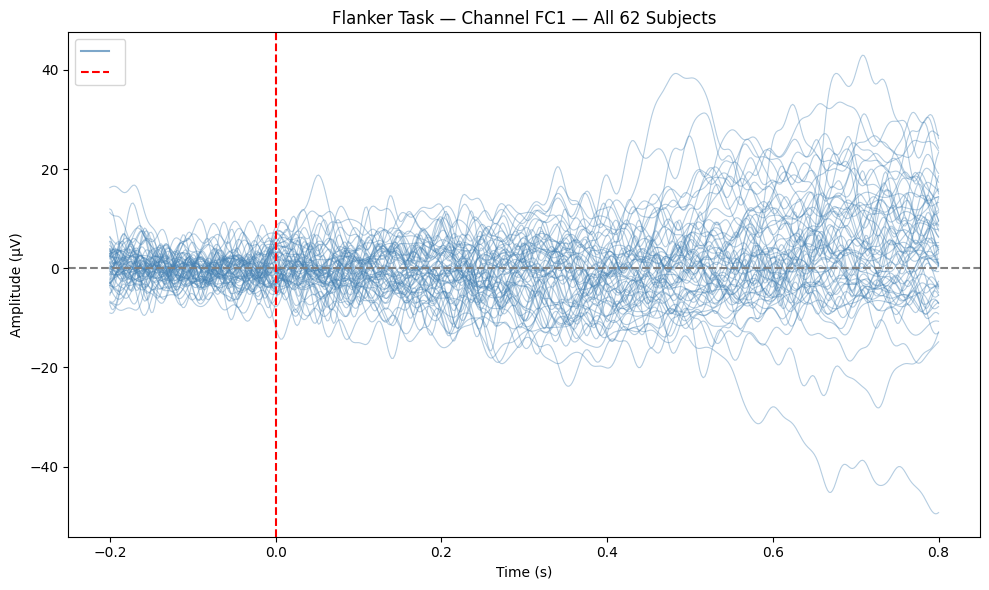

Saved: 00_all_curves.pdf


In [4]:
np.random.seed(42)

dat      = pd.read_csv("./EDA/Flanker_stimulus_FC1_channel.csv")
time_vec = dat["time"].to_numpy()
Y_mat    = dat.drop(columns="time").to_numpy()   # shape: (501, 62)
n_subj   = Y_mat.shape[1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_vec, Y_mat, color="steelblue", alpha=0.4, linewidth=0.8)
ax.axhline(0, linestyle="--", color="grey", linewidth=1.5)
ax.axvline(0, linestyle="--", color="red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title(f"Flanker Task — Channel FC1 — All {n_subj} Subjects")
ax.legend(["Individual subjects", "Stimulus onset"],
          handles=[plt.Line2D([0],[0],color="steelblue",alpha=0.7),
                   plt.Line2D([0],[0],color="red",linestyle="--")], loc="upper left")
plt.tight_layout()
plt.savefig(out_dir / "00_all_curves.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 00_all_curves.pdf")


# Step 1: Smoothing

In [5]:
time_range = (time_vec[0], time_vec[-1])
norder     = 4   # cubic B-splines
nbasis     = 20

basis = BSplineBasis(domain_range=time_range, n_basis=nbasis, order=norder)

# Build FDataGrid (one curve per subject)
fd_grid = FDataGrid(data_matrix=Y_mat.T, grid_points=time_vec)

print(f"Time points: {len(time_vec)}")
print(f"Time range:  {time_range}")
print(f"Subjects:    {n_subj}")
print(f"Basis functions: {nbasis}")


Time points: 501
Time range:  (np.float64(-0.2), np.float64(0.8))
Subjects:    62
Basis functions: 20


## GCV to choose lambda

In [6]:
# Basis evaluation matrix at time_vec
from skfda.representation.basis import BSplineBasis
import numpy as np

loglam  = np.arange(-5, 10.5, 0.5)
nlam    = len(loglam)
gcvsave = np.full(nlam, np.nan)
dfsave  = np.full(nlam, np.nan)

n_t = len(time_vec)
n_s = Y_mat.shape[1]

# Evaluate basis at time_vec: shape (n_t, nbasis)
B = basis.evaluate(time_vec).squeeze().T  # (n_t, nbasis)

# Roughness penalty matrix: integral of (D^2 phi_i)(D^2 phi_j)
# Build via inner products of second derivatives
D2B = basis.evaluate(time_vec, derivative=2).squeeze().T  # (n_t, nbasis)
R   = (D2B.T @ D2B) * (time_vec[1] - time_vec[0])  # trapezoidal approx

BtB = B.T @ B

for ilam, lam_log in enumerate(loglam):
    lam = 10**lam_log
    A   = BtB + lam * R                   # (nbasis, nbasis)
    H   = B @ np.linalg.solve(A, B.T)     # hat matrix (n_t, n_t)
    df  = np.trace(H)
    
    coef = np.linalg.solve(A, B.T @ Y_mat)  # (nbasis, n_s)
    yhat = B @ coef                          # (n_t, n_s)
    rss  = np.sum((Y_mat - yhat)**2)
    
    gcv  = (n_t * n_s * rss / n_s) / (n_t - df)**2
    gcvsave[ilam] = gcv
    dfsave[ilam]  = df
    print(f"log10 lambda = {lam_log:.1f}  |  df = {df:.2f}  |  GCV = {gcv:.4f}")

best_idx    = np.argmin(gcvsave)
best_lambda = 10**loglam[best_idx]

print(f"\n=== GCV RESULT ===")
print(f"Optimal log10(lambda): {loglam[best_idx]}")
print(f"Optimal lambda:        {best_lambda}")
print(f"Optimal df:            {dfsave[best_idx]:.2f}")
print("==================")


log10 lambda = -5.0  |  df = 18.35  |  GCV = 289.8788
log10 lambda = -4.5  |  df = 16.94  |  GCV = 299.1741
log10 lambda = -4.0  |  df = 14.91  |  GCV = 325.1988
log10 lambda = -3.5  |  df = 12.44  |  GCV = 381.7561
log10 lambda = -3.0  |  df = 10.01  |  GCV = 470.0267
log10 lambda = -2.5  |  df = 7.92  |  GCV = 588.2516
log10 lambda = -2.0  |  df = 6.25  |  GCV = 730.7743
log10 lambda = -1.5  |  df = 4.96  |  GCV = 886.7754
log10 lambda = -1.0  |  df = 3.97  |  GCV = 1049.4656
log10 lambda = -0.5  |  df = 3.23  |  GCV = 1210.3611
log10 lambda = 0.0  |  df = 2.68  |  GCV = 1375.1566
log10 lambda = 0.5  |  df = 2.30  |  GCV = 1542.0500
log10 lambda = 1.0  |  df = 2.11  |  GCV = 1653.3041
log10 lambda = 1.5  |  df = 2.04  |  GCV = 1702.1148
log10 lambda = 2.0  |  df = 2.01  |  GCV = 1719.4773
log10 lambda = 2.5  |  df = 2.00  |  GCV = 1725.1855
log10 lambda = 3.0  |  df = 2.00  |  GCV = 1727.0132
log10 lambda = 3.5  |  df = 2.00  |  GCV = 1727.5935
log10 lambda = 4.0  |  df = 2.00  |  GC

/tmp/ipykernel_2735164/1646957244.py:14: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B = basis.evaluate(time_vec).squeeze().T  # (n_t, nbasis)
/tmp/ipykernel_2735164/1646957244.py:18: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  D2B = basis.evaluate(time_vec, derivative=2).squeeze().T  # (n_t, nbasis)


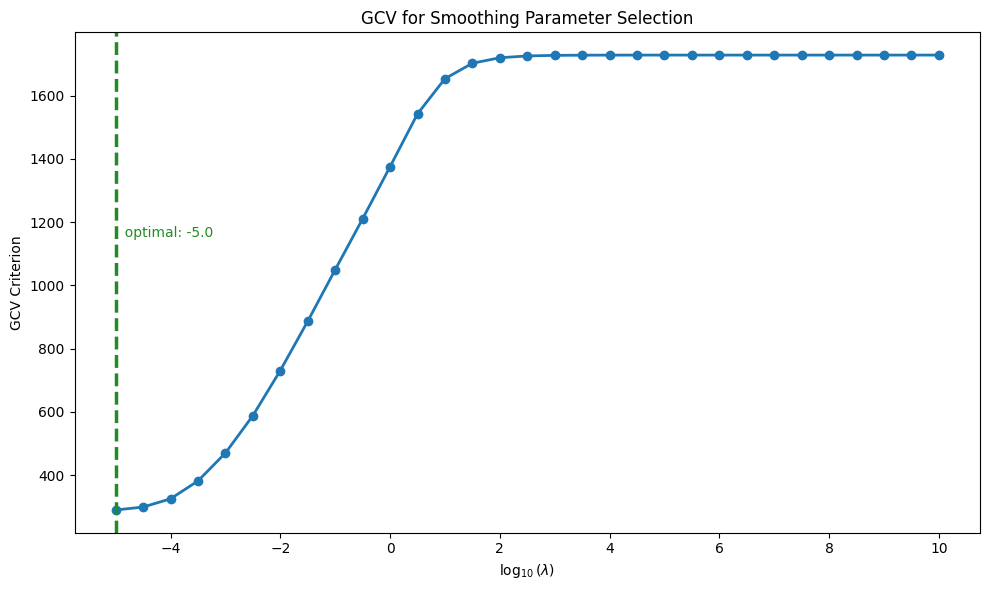

Saved: 01_gcv_lambda.pdf


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(loglam, gcvsave, "o-", linewidth=2)
ax.axvline(loglam[best_idx], linestyle="--", color="forestgreen", linewidth=2.5)
y_pos = np.min(gcvsave) + 0.6 * (np.max(gcvsave) - np.min(gcvsave))
ax.text(loglam[best_idx], y_pos, f"  optimal: {loglam[best_idx]}",
        color="forestgreen")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("GCV Criterion")
ax.set_title("GCV for Smoothing Parameter Selection")
plt.tight_layout()
plt.savefig(out_dir / "01_gcv_lambda.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 01_gcv_lambda.pdf")


## Smooth with optimal lambda

In [8]:
lam_opt = best_lambda
A_opt   = BtB + lam_opt * R
coef_opt = np.linalg.solve(A_opt, B.T @ Y_mat)   # (nbasis, n_subj)
yhat_opt = B @ coef_opt                            # (n_t, n_subj)

# Store as FDataGrid (smoothed values on original grid)
fd_smooth = FDataGrid(data_matrix=yhat_opt.T, grid_points=time_vec)
subject_ids = dat.columns[1:].tolist()
fd_smooth.sample_names = subject_ids

print(f"Smoothed fd object: {fd_smooth.n_samples} curves x {fd_smooth.data_matrix.shape[1]} time points")


Smoothed fd object: 62 curves x 501 time points


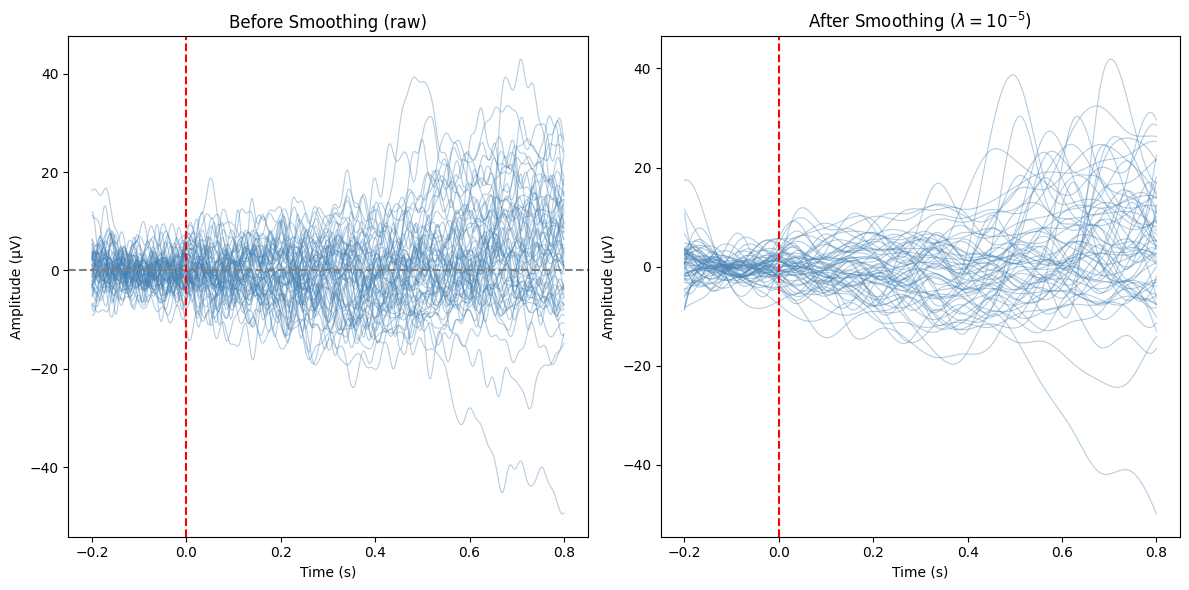

Saved: 02_before_after_smoothing.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(time_vec, Y_mat, color="steelblue", alpha=0.4, linewidth=0.8)
axes[0].axhline(0, linestyle="--", color="grey", linewidth=1.5)
axes[0].axvline(0, linestyle="--", color="red")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].set_title("Before Smoothing (raw)")

axes[1].plot(time_vec, yhat_opt, color="steelblue", alpha=0.4, linewidth=0.8)
axes[1].axvline(0, linestyle="--", color="red")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_title(rf"After Smoothing ($\lambda = 10^{{{loglam[best_idx]:.0f}}}$)")

plt.tight_layout()
plt.savefig(out_dir / "02_before_after_smoothing.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 02_before_after_smoothing.pdf")


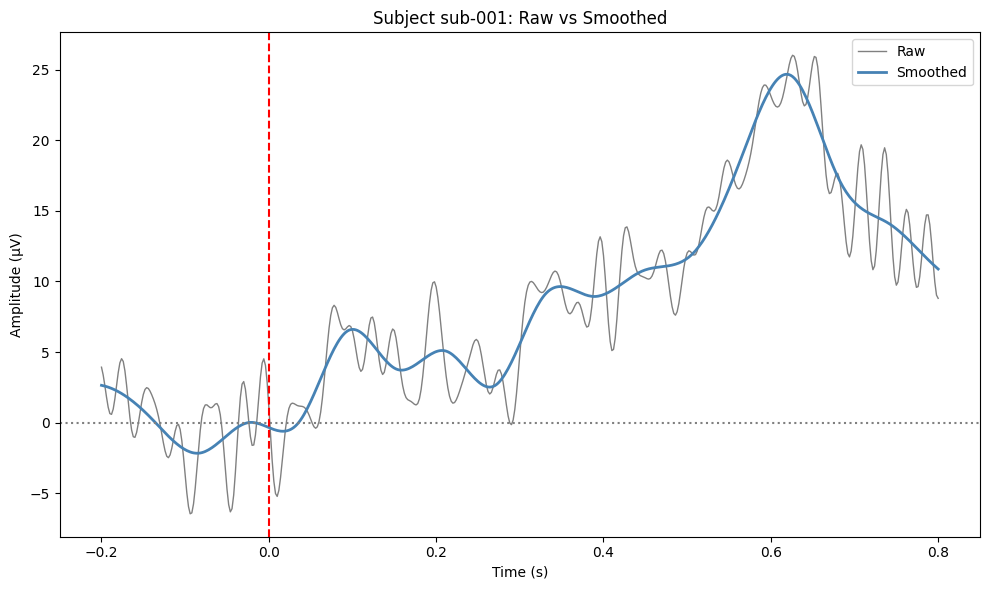

Saved: 03_single_subject_fit.pdf


In [10]:
sub_idx = 0
y_raw   = Y_mat[:, sub_idx]
y_fit   = yhat_opt[:, sub_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_vec, y_raw, color="grey", linewidth=1, label="Raw")
ax.plot(time_vec, y_fit, color="steelblue", linewidth=2, label="Smoothed")
ax.axhline(0, linestyle=":", color="grey", linewidth=1.5)
ax.axvline(0, linestyle="--", color="red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title(f"Subject {subject_ids[sub_idx]}: Raw vs Smoothed")
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "03_single_subject_fit.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 03_single_subject_fit.pdf")


In [11]:
with open(out_dir / "fd_smooth.pkl", "wb") as f:
    pickle.dump({"fd_smooth": fd_smooth, "coef_opt": coef_opt,
                 "basis": basis, "lam_opt": lam_opt,
                 "time_vec": time_vec, "subject_ids": subject_ids}, f)
print(f"Smoothed fd object saved to: {out_dir / 'fd_smooth.pkl'}")


Smoothed fd object saved to: EDA/outputs/fd_smooth.pkl


# Step 2: Functional EDA

In [12]:
with open(out_dir / "fd_smooth.pkl", "rb") as f:
    d = pickle.load(f)

fd_smooth   = d["fd_smooth"]
coef_opt    = d["coef_opt"]
basis       = d["basis"]
lam_opt     = d["lam_opt"]
time_vec    = d["time_vec"]
subject_ids = d["subject_ids"]

# Evaluate on a fine grid (501 points)
t_fine = np.linspace(time_vec[0], time_vec[-1], 501)

# Evaluate smoothed curves on fine grid using basis coefficients
B_fine = basis.evaluate(t_fine).squeeze().T    # (501, nbasis)
Y_eval = B_fine @ coef_opt                     # (501, n_subj)
n_subj = Y_eval.shape[1]

print(f"Loaded smoothed fd object")
print(f"Subjects: {n_subj}, fine grid: {len(t_fine)} points")


Loaded smoothed fd object
Subjects: 62, fine grid: 501 points


/tmp/ipykernel_2735164/573579062.py:15: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_fine = basis.evaluate(t_fine).squeeze().T    # (501, nbasis)


## Part 1: Mean, SD, Covariance

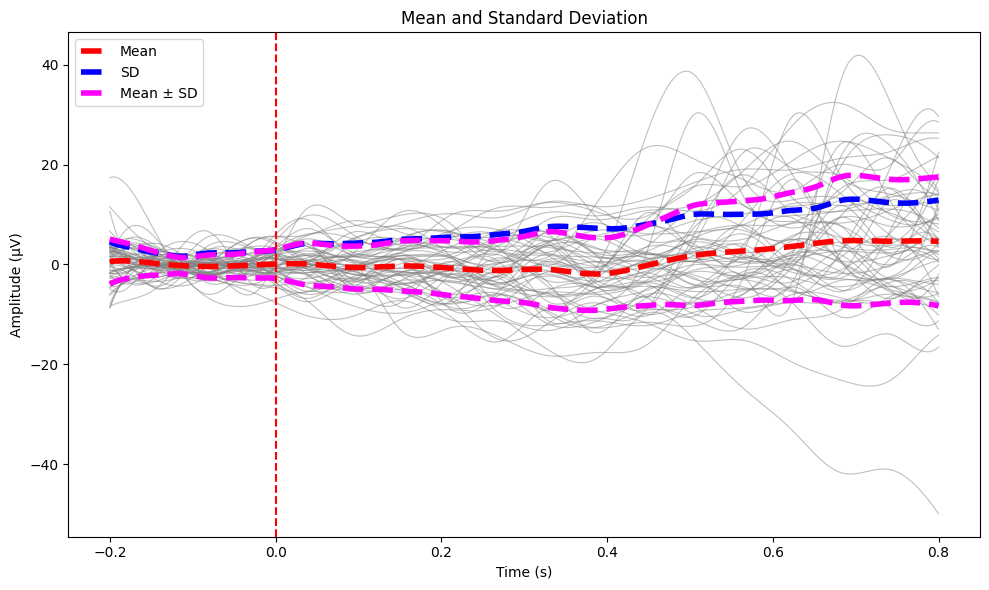

Saved: 04_mean_sd.pdf


In [13]:
mean_curve = np.mean(Y_eval, axis=1)
sd_curve   = np.std(Y_eval, axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_fine, Y_eval, color="gray", linewidth=0.8, alpha=0.5)
ax.plot(t_fine, mean_curve,             color="red",    linewidth=4, linestyle="--", label="Mean")
ax.plot(t_fine, sd_curve,               color="blue",   linewidth=4, linestyle="--", label="SD")
ax.plot(t_fine, mean_curve - sd_curve,  color="magenta",linewidth=4, linestyle="--", label="Mean ± SD")
ax.plot(t_fine, mean_curve + sd_curve,  color="magenta",linewidth=4, linestyle="--")
ax.axvline(0, linestyle="--", color="red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Mean and Standard Deviation")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(out_dir / "04_mean_sd.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 04_mean_sd.pdf")


/tmp/ipykernel_2735164/2556529423.py:3: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_cov   = basis.evaluate(t_grid).squeeze().T    # (101, nbasis)


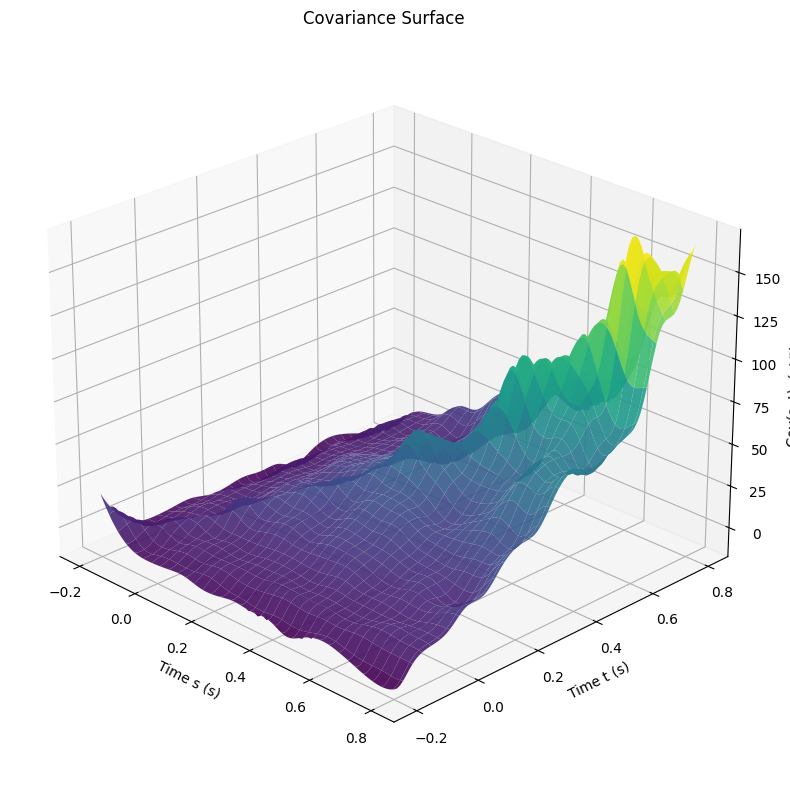

Saved: 05_covariance_persp.pdf


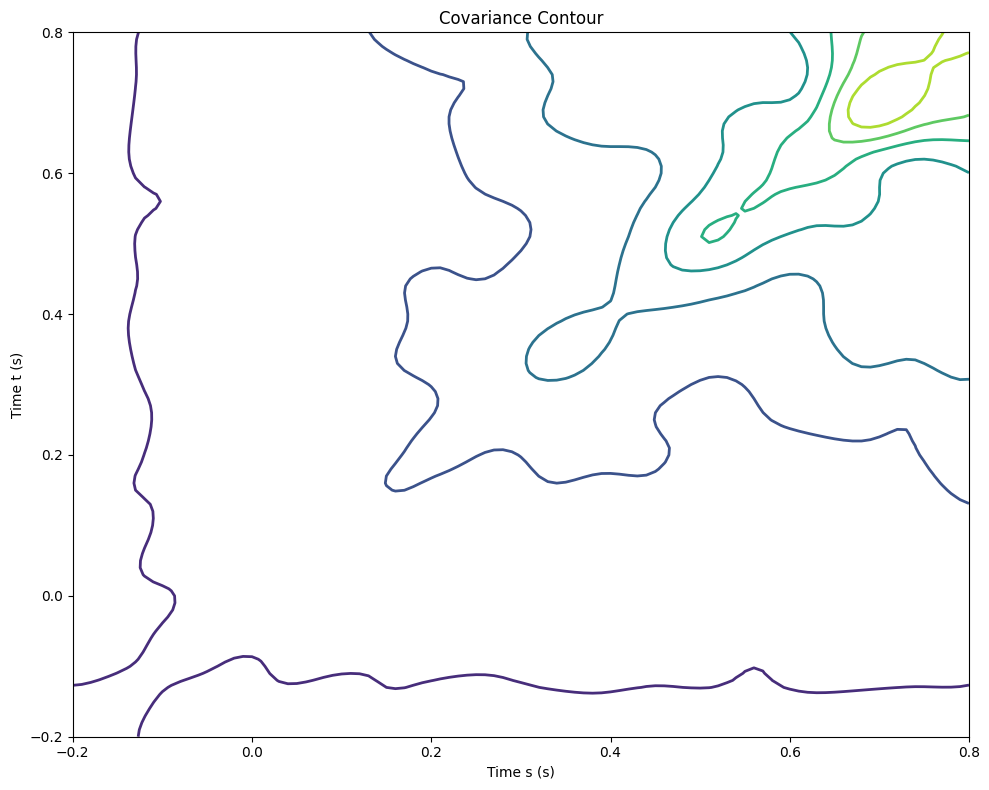

Saved: 06_covariance_contour.pdf


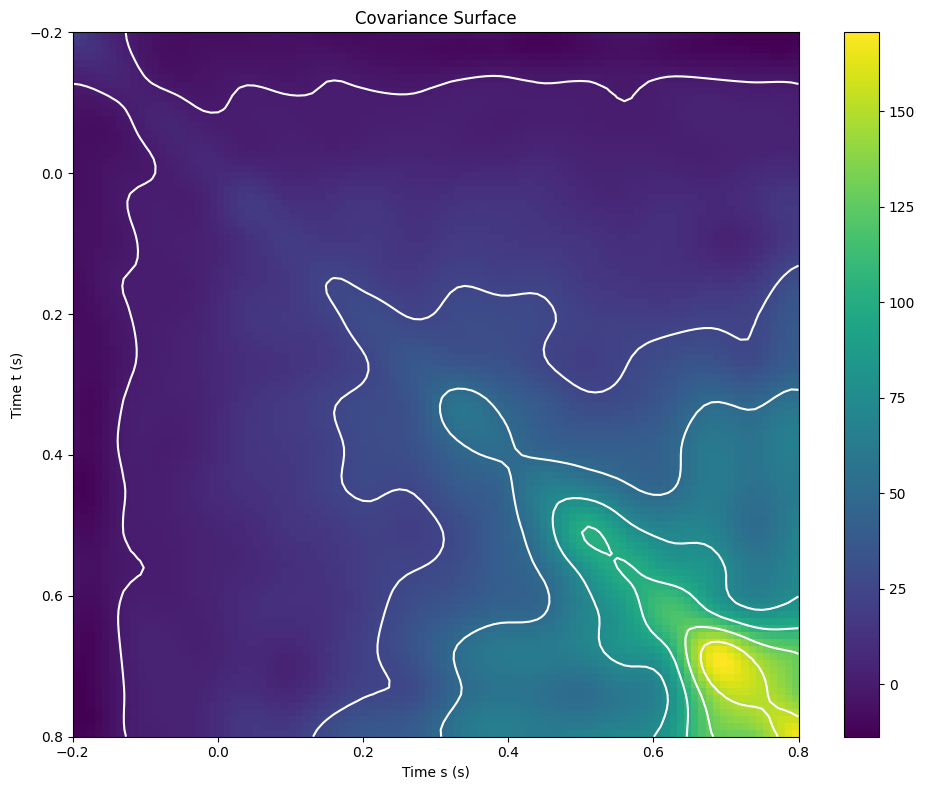

Saved: 07_covariance_image.pdf


In [14]:
# Evaluate on coarser grid for covariance (101 points)
t_grid  = np.linspace(time_vec[0], time_vec[-1], 101)
B_cov   = basis.evaluate(t_grid).squeeze().T    # (101, nbasis)
Y_cov   = B_cov @ coef_opt                       # (101, n_subj)
cov_mat = np.cov(Y_cov)                           # (101, 101)

# 05: Perspective plot
from mpl_toolkits.mplot3d import Axes3D
T1, T2 = np.meshgrid(t_grid, t_grid)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(T1, T2, cov_mat, cmap="viridis", alpha=0.9)
ax.set_xlabel("Time s (s)")
ax.set_ylabel("Time t (s)")
ax.set_zlabel("Cov(s, t)  (µV²)")
ax.set_title("Covariance Surface")
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.savefig(out_dir / "05_covariance_persp.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 05_covariance_persp.pdf")

# 06: Contour
fig, ax = plt.subplots(figsize=(10, 8))
ax.contour(t_grid, t_grid, cov_mat, linewidths=2)
ax.set_xlabel("Time s (s)")
ax.set_ylabel("Time t (s)")
ax.set_title("Covariance Contour")
plt.tight_layout()
plt.savefig(out_dir / "06_covariance_contour.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 06_covariance_contour.pdf")

# 07: Image
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cov_mat, extent=[t_grid[0], t_grid[-1], t_grid[-1], t_grid[0]],
               aspect='auto', cmap='viridis')
ax.contour(t_grid, t_grid, cov_mat, colors='white')
plt.colorbar(im, ax=ax)
ax.set_xlabel("Time s (s)")
ax.set_ylabel("Time t (s)")
ax.set_title("Covariance Surface")
plt.tight_layout()
plt.savefig(out_dir / "07_covariance_image.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved: 07_covariance_image.pdf")


## Part 2: Centrality and Dispersion

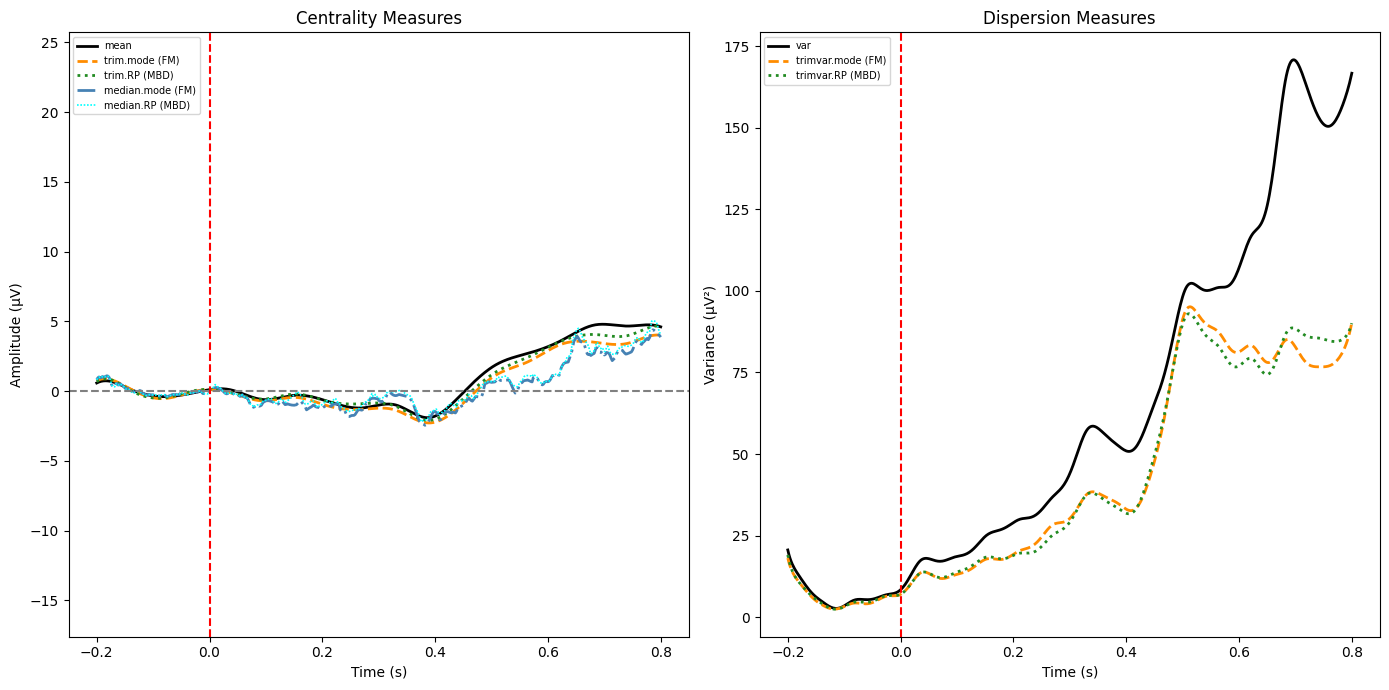

Saved: 08_centrality_dispersion.pdf


In [15]:
# Depth measures for trimmed means
fd_eval = FDataGrid(data_matrix=Y_eval.T, grid_points=t_fine)

# Fraiman-Muniz depth
fm_depth  = IntegratedDepth().fit_transform(fd_eval)
# Modified Band Depth (approximates mode/RP depths)
mbd_depth = ModifiedBandDepth().fit_transform(fd_eval)
bd_depth  = BandDepth().fit_transform(fd_eval)

def trimmed_mean_curve(Y, depth_vals, trim=0.15):
    n      = Y.shape[1]
    n_keep = max(1, int(n * (1 - trim)))
    idx    = np.argsort(depth_vals)[::-1][:n_keep]
    return np.mean(Y[:, idx], axis=1)

def trimmed_median_curve(Y, depth_vals, trim=0.15):
    n      = Y.shape[1]
    n_keep = max(1, int(n * (1 - trim)))
    idx    = np.argsort(depth_vals)[::-1][:n_keep]
    return np.median(Y[:, idx], axis=1)

yrng = np.quantile(Y_eval, [0.01, 0.99])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.plot(t_fine, mean_curve,                                   color='black', linewidth=2, label='mean')
ax.plot(t_fine, trimmed_mean_curve(Y_eval, fm_depth,  0.15),  color='#FF8C00',    linestyle='--', linewidth=2, label='trim.mode (FM)')
ax.plot(t_fine, trimmed_mean_curve(Y_eval, mbd_depth, 0.15),  color='forestgreen',linestyle=':',  linewidth=2, label='trim.RP (MBD)')
ax.plot(t_fine, trimmed_median_curve(Y_eval, fm_depth,  0.15),color='steelblue',  linestyle='-.',  linewidth=2, label='median.mode (FM)')
ax.plot(t_fine, trimmed_median_curve(Y_eval, mbd_depth, 0.15),color='cyan',       linestyle=(0,(1,1)), linewidth=1.2, label='median.RP (MBD)')
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_ylim(yrng)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Centrality Measures')
ax.legend(fontsize=7, loc='upper left')

var_curve      = np.var(Y_eval, axis=1, ddof=1)
trimvar_fm     = np.var(Y_eval[:, np.argsort(fm_depth)[::-1][:int(n_subj*0.85)]], axis=1, ddof=1)
trimvar_mbd    = np.var(Y_eval[:, np.argsort(mbd_depth)[::-1][:int(n_subj*0.85)]], axis=1, ddof=1)

ax = axes[1]
ax.plot(t_fine, var_curve,   color='black',       linewidth=2, label='var')
ax.plot(t_fine, trimvar_fm,  color='#FF8C00',     linestyle='--', linewidth=2, label='trimvar.mode (FM)')
ax.plot(t_fine, trimvar_mbd, color='forestgreen', linestyle=':', linewidth=2, label='trimvar.RP (MBD)')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Variance (µV²)')
ax.set_title('Dispersion Measures')
ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(out_dir / '08_centrality_dispersion.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 08_centrality_dispersion.pdf')


## Part 3: Functional Depth

/tmp/ipykernel_2735164/2979939316.py:18: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(['All curves', 'Central curves', f'Trimmed mean ({int(trim*100)}%)', 'Median'],


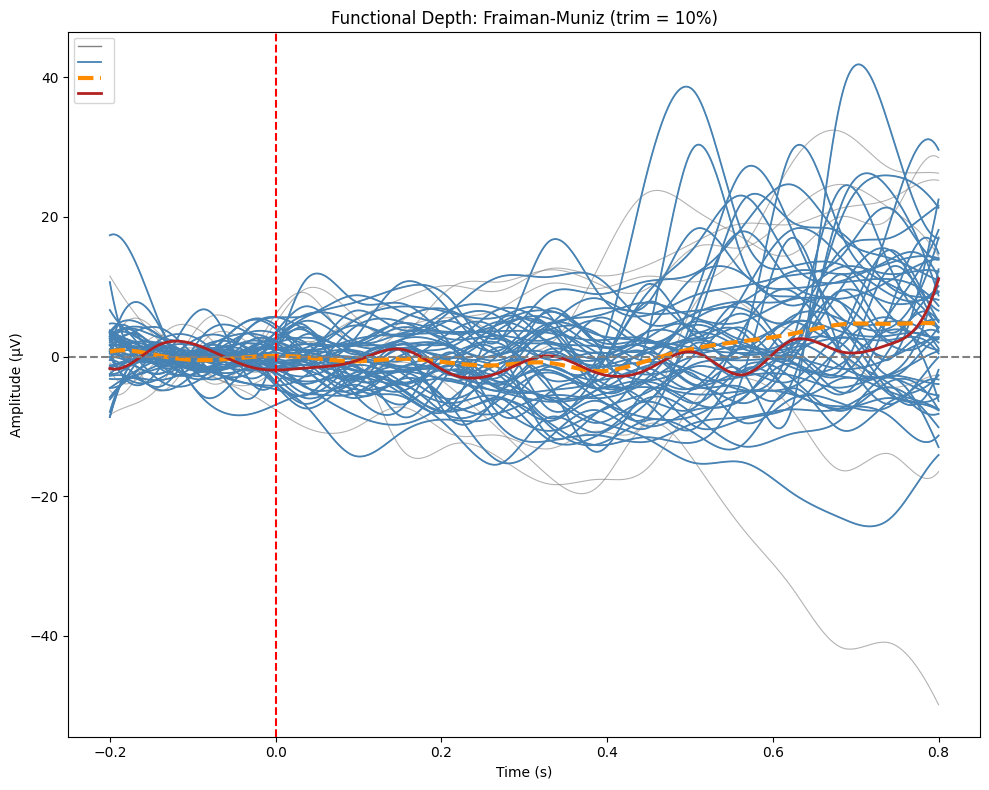

Saved: 09_depth_FM.pdf


/tmp/ipykernel_2735164/2979939316.py:18: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(['All curves', 'Central curves', f'Trimmed mean ({int(trim*100)}%)', 'Median'],


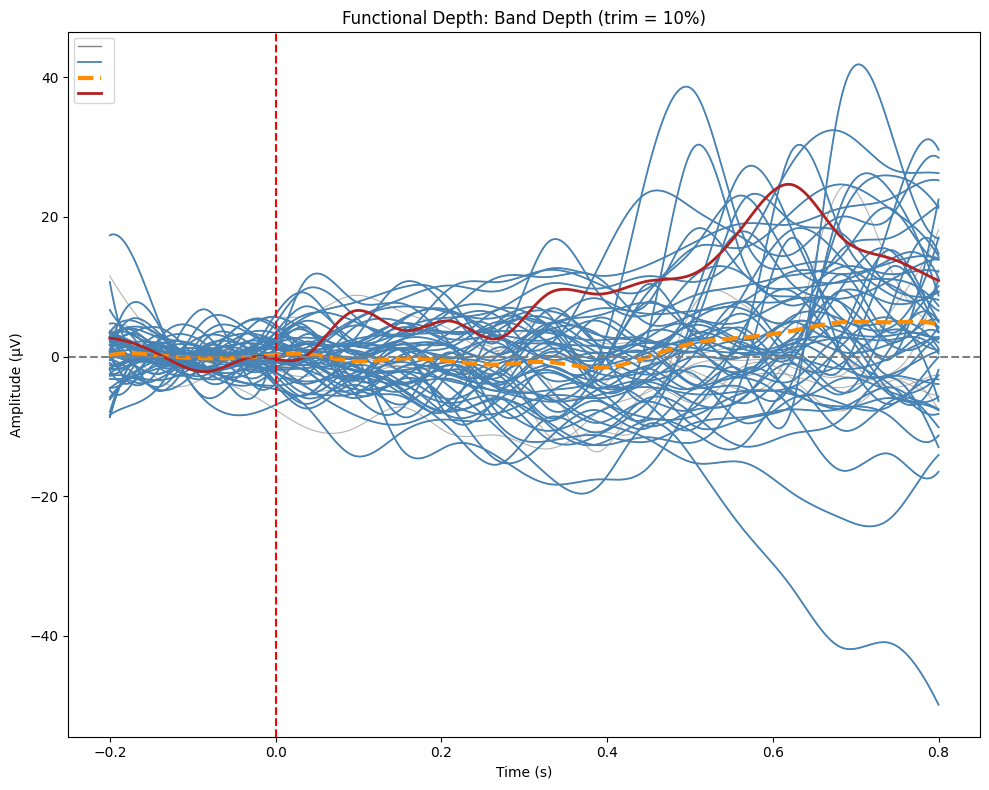

Saved: 10_depth_mode.pdf


/tmp/ipykernel_2735164/2979939316.py:18: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(['All curves', 'Central curves', f'Trimmed mean ({int(trim*100)}%)', 'Median'],


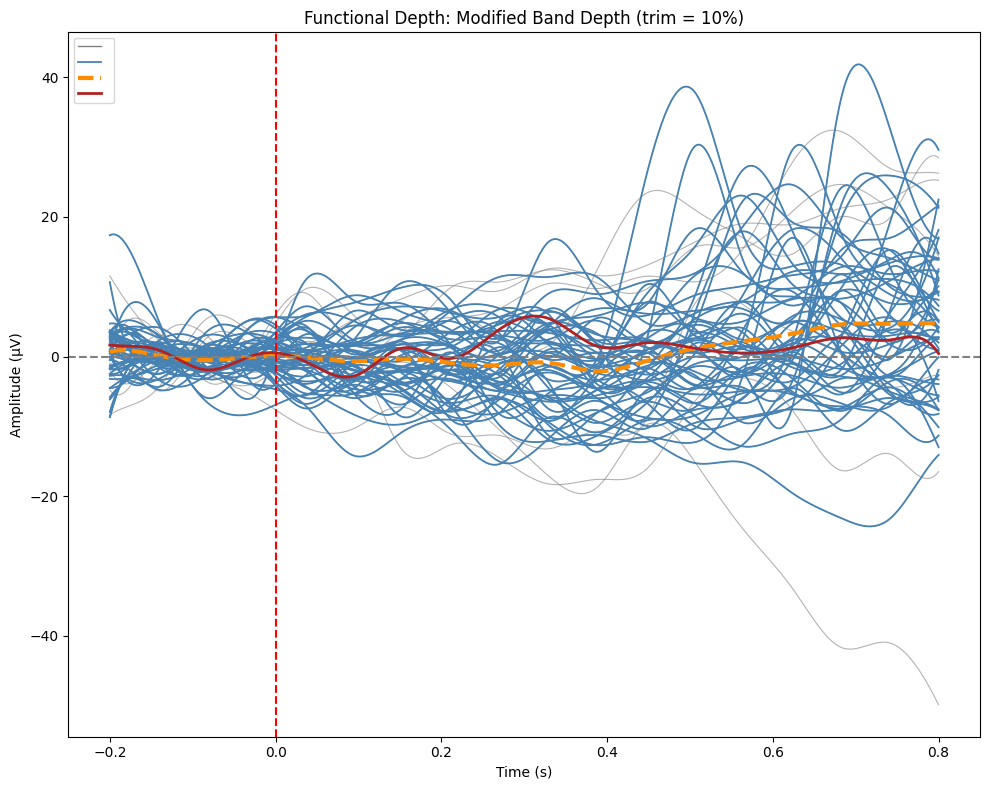

Saved: 11_depth_RP.pdf


In [16]:
def plot_depth(Y, t, depth_vals, title, fname, trim=0.1):
    n      = Y.shape[1]
    n_keep = max(1, int(n * (1 - trim)))
    idx_c  = np.argsort(depth_vals)[::-1][:n_keep]  # central curves
    med_idx = np.argmax(depth_vals)                  # deepest = median
    trimmed_mean = np.mean(Y[:, idx_c], axis=1)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(t, Y,              color='grey',       linewidth=0.8, alpha=0.6)
    ax.plot(t, Y[:, idx_c],    color='steelblue',  linewidth=1.3)
    ax.plot(t, trimmed_mean,   color='#FF8C00',    linewidth=3, linestyle='--')
    ax.plot(t, Y[:, med_idx],  color='firebrick',  linewidth=2)
    ax.axhline(0, linestyle='--', color='grey')
    ax.axvline(0, linestyle='--', color='red')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(title)
    ax.legend(['All curves', 'Central curves', f'Trimmed mean ({int(trim*100)}%)', 'Median'],
              handles=[
                  plt.Line2D([0],[0], color='grey',      linewidth=1),
                  plt.Line2D([0],[0], color='steelblue', linewidth=1.3),
                  plt.Line2D([0],[0], color='#FF8C00',   linewidth=3, linestyle='--'),
                  plt.Line2D([0],[0], color='firebrick', linewidth=2),
              ], loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / fname, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

plot_depth(Y_eval, t_fine, fm_depth,  'Functional Depth: Fraiman-Muniz (trim = 10%)', '09_depth_FM.pdf')
plot_depth(Y_eval, t_fine, bd_depth,  'Functional Depth: Band Depth (trim = 10%)',    '10_depth_mode.pdf')
plot_depth(Y_eval, t_fine, mbd_depth, 'Functional Depth: Modified Band Depth (trim = 10%)', '11_depth_RP.pdf')


## Part 4: PCA

In [17]:
nharm  = 4
fpca   = FPCA(n_components=nharm)
fpca.fit(fd_eval)

scores   = fpca.transform(fd_eval)            # (n_subj, nharm)
var_prop = fpca.explained_variance_ratio_

print('Variance proportions:')
print(var_prop)
print('Cumulative:', np.cumsum(var_prop))

harmonics = fpca.components_.evaluate(t_fine).squeeze().T  # (501, nharm)
mean_vec  = fpca.mean_.evaluate(t_fine).squeeze()           # (501,)


Variance proportions:
[0.62629767 0.1178661  0.10352206 0.04366907]
Cumulative: [0.62629767 0.74416377 0.84768583 0.8913549 ]


/tmp/ipykernel_2735164/3396376300.py:12: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  harmonics = fpca.components_.evaluate(t_fine).squeeze().T  # (501, nharm)
/tmp/ipykernel_2735164/3396376300.py:13: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  mean_vec  = fpca.mean_.evaluate(t_fine).squeeze()           # (501,)


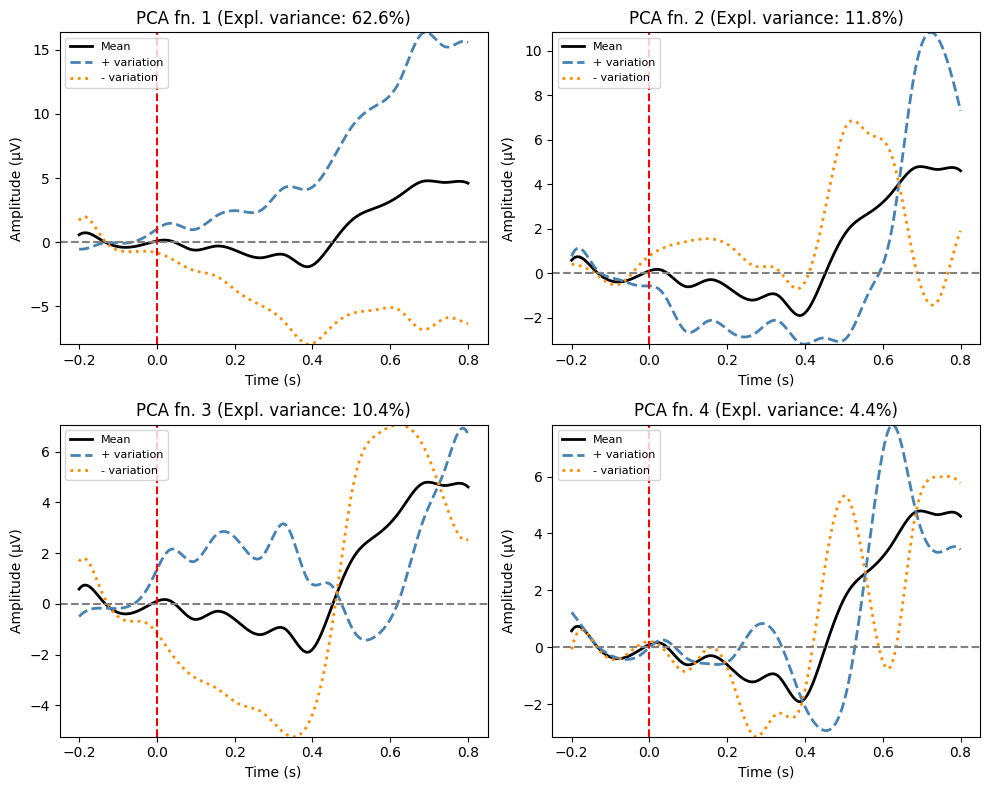

Saved: 12_pca_plot.pdf


In [18]:
# 12: PCA plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    fac      = np.sqrt(fpca.explained_variance_[i])
    pc_plus  = mean_vec + fac * harmonics[:, i]
    pc_minus = mean_vec - fac * harmonics[:, i]
    ylim_i   = (min(mean_vec.min(), pc_plus.min(), pc_minus.min()),
                max(mean_vec.max(), pc_plus.max(), pc_minus.max()))
    ax.plot(t_fine, mean_vec,  color='black',      linewidth=2, label='Mean')
    ax.plot(t_fine, pc_plus,   color='steelblue',  linewidth=2, linestyle='--', label='+ variation')
    ax.plot(t_fine, pc_minus,  color='#FF8C00',    linewidth=2, linestyle=':', label='- variation')
    ax.axhline(0, linestyle='--', color='grey')
    ax.axvline(0, linestyle='--', color='red')
    ax.set_ylim(ylim_i)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'PCA fn. {i+1} (Expl. variance: {100*var_prop[i]:.1f}%)')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(out_dir / '12_pca_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 12_pca_plot.pdf')


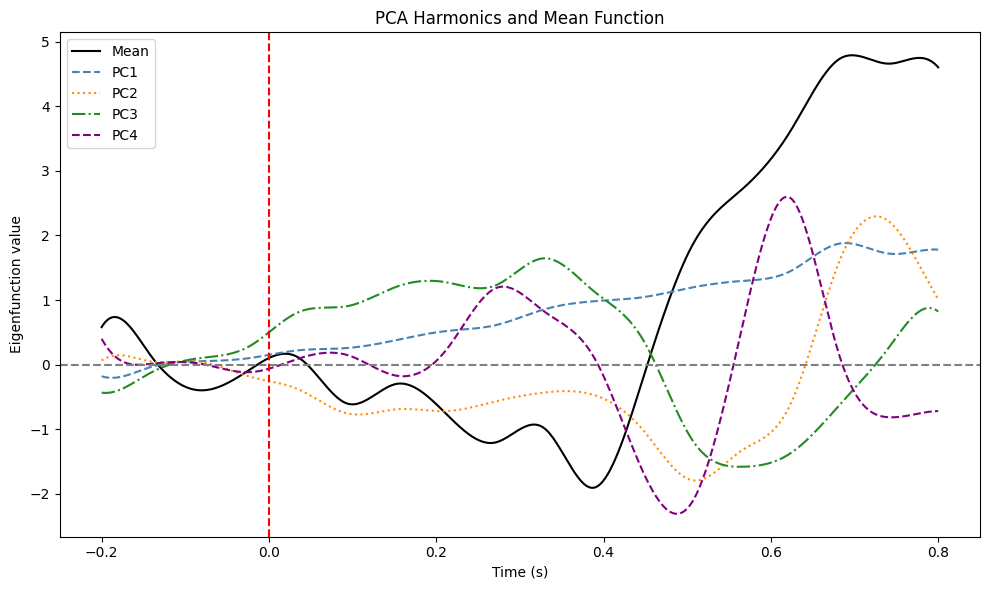

Saved: 13_pca_harmonics.pdf


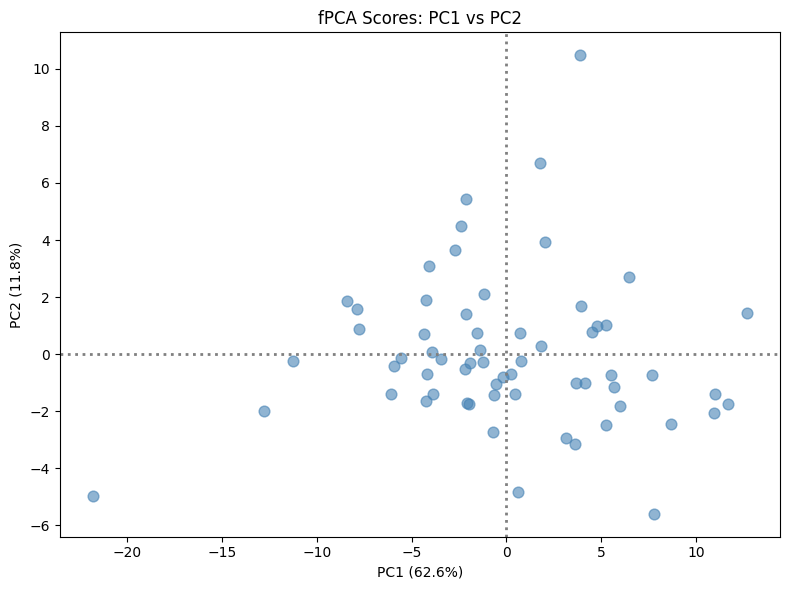

Saved: 14_pca_scores.pdf


In [19]:
# 13: PCA harmonics
fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['black', 'steelblue', '#FF8C00', 'forestgreen', 'purple']
labels  = ['Mean'] + [f'PC{i+1}' for i in range(nharm)]
for i, (col, lab) in enumerate(zip(colors, labels)):
    curve = mean_vec if i == 0 else harmonics[:, i-1]
    ax.plot(t_fine, curve, color=col, linestyle=['-','--',':','-.','--'][i],
            linewidth=1.5, label=lab)
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Eigenfunction value')
ax.set_title('PCA Harmonics and Mean Function')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / '13_pca_harmonics.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 13_pca_harmonics.pdf')

# 14: PCA scores
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scores[:, 0], scores[:, 1],
           color='steelblue', alpha=0.6, s=60)
ax.axhline(0, linestyle=':', color='grey', linewidth=2)
ax.axvline(0, linestyle=':', color='grey', linewidth=2)
ax.set_xlabel(f'PC1 ({100*var_prop[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({100*var_prop[1]:.1f}%)')
ax.set_title('fPCA Scores: PC1 vs PC2')
plt.tight_layout()
plt.savefig(out_dir / '14_pca_scores.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 14_pca_scores.pdf')


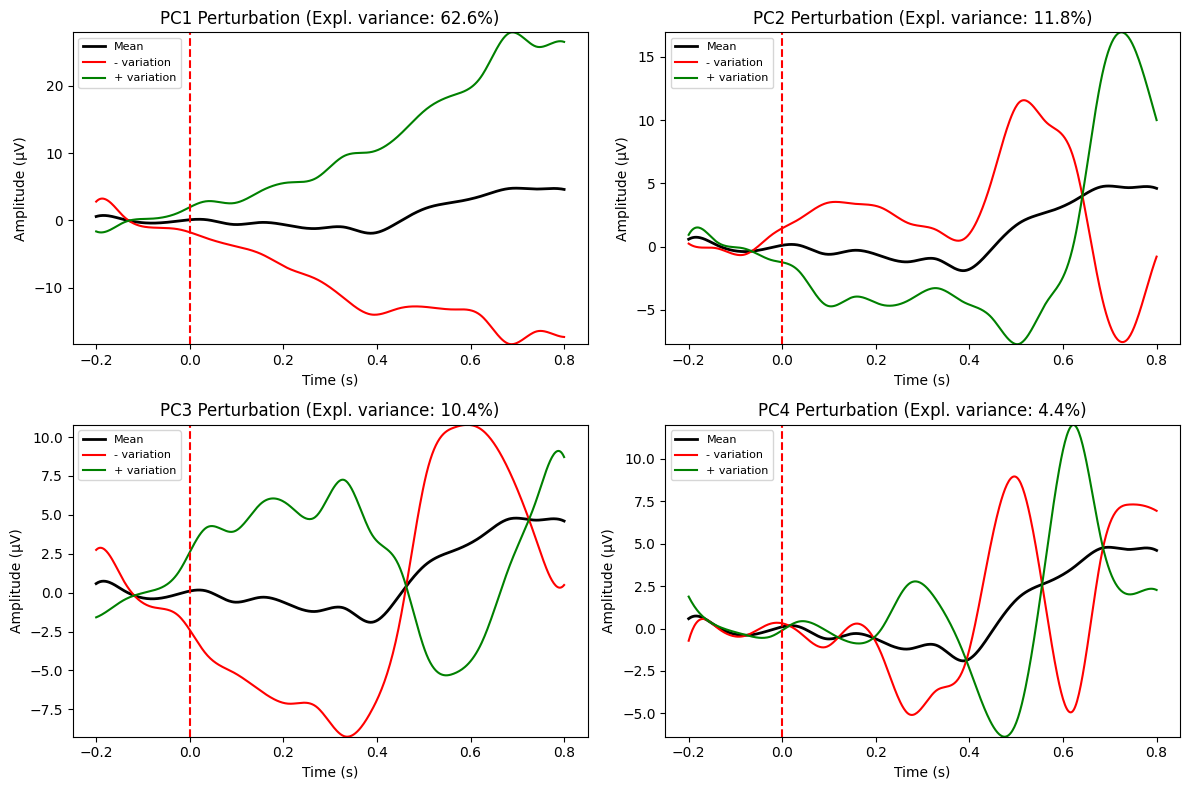

Saved: 15_pca_perturbation.pdf


In [20]:
# 15: Perturbation plots
c   = 2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for k, ax in enumerate(axes.flat):
    fac   = np.sqrt(fpca.explained_variance_[k])
    f1    = mean_vec - c * fac * harmonics[:, k]
    f2    = mean_vec + c * fac * harmonics[:, k]
    ylim  = (min(f1.min(), f2.min()), max(f1.max(), f2.max()))
    ax.plot(t_fine, mean_vec, color='black',  linewidth=2,   label='Mean')
    ax.plot(t_fine, f1,       color='red',    linewidth=1.5, label='- variation')
    ax.plot(t_fine, f2,       color='green',  linewidth=1.5, label='+ variation')
    ax.axvline(0, linestyle='--', color='red')
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'PC{k+1} Perturbation (Expl. variance: {100*var_prop[k]:.1f}%)')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(out_dir / '15_pca_perturbation.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 15_pca_perturbation.pdf')


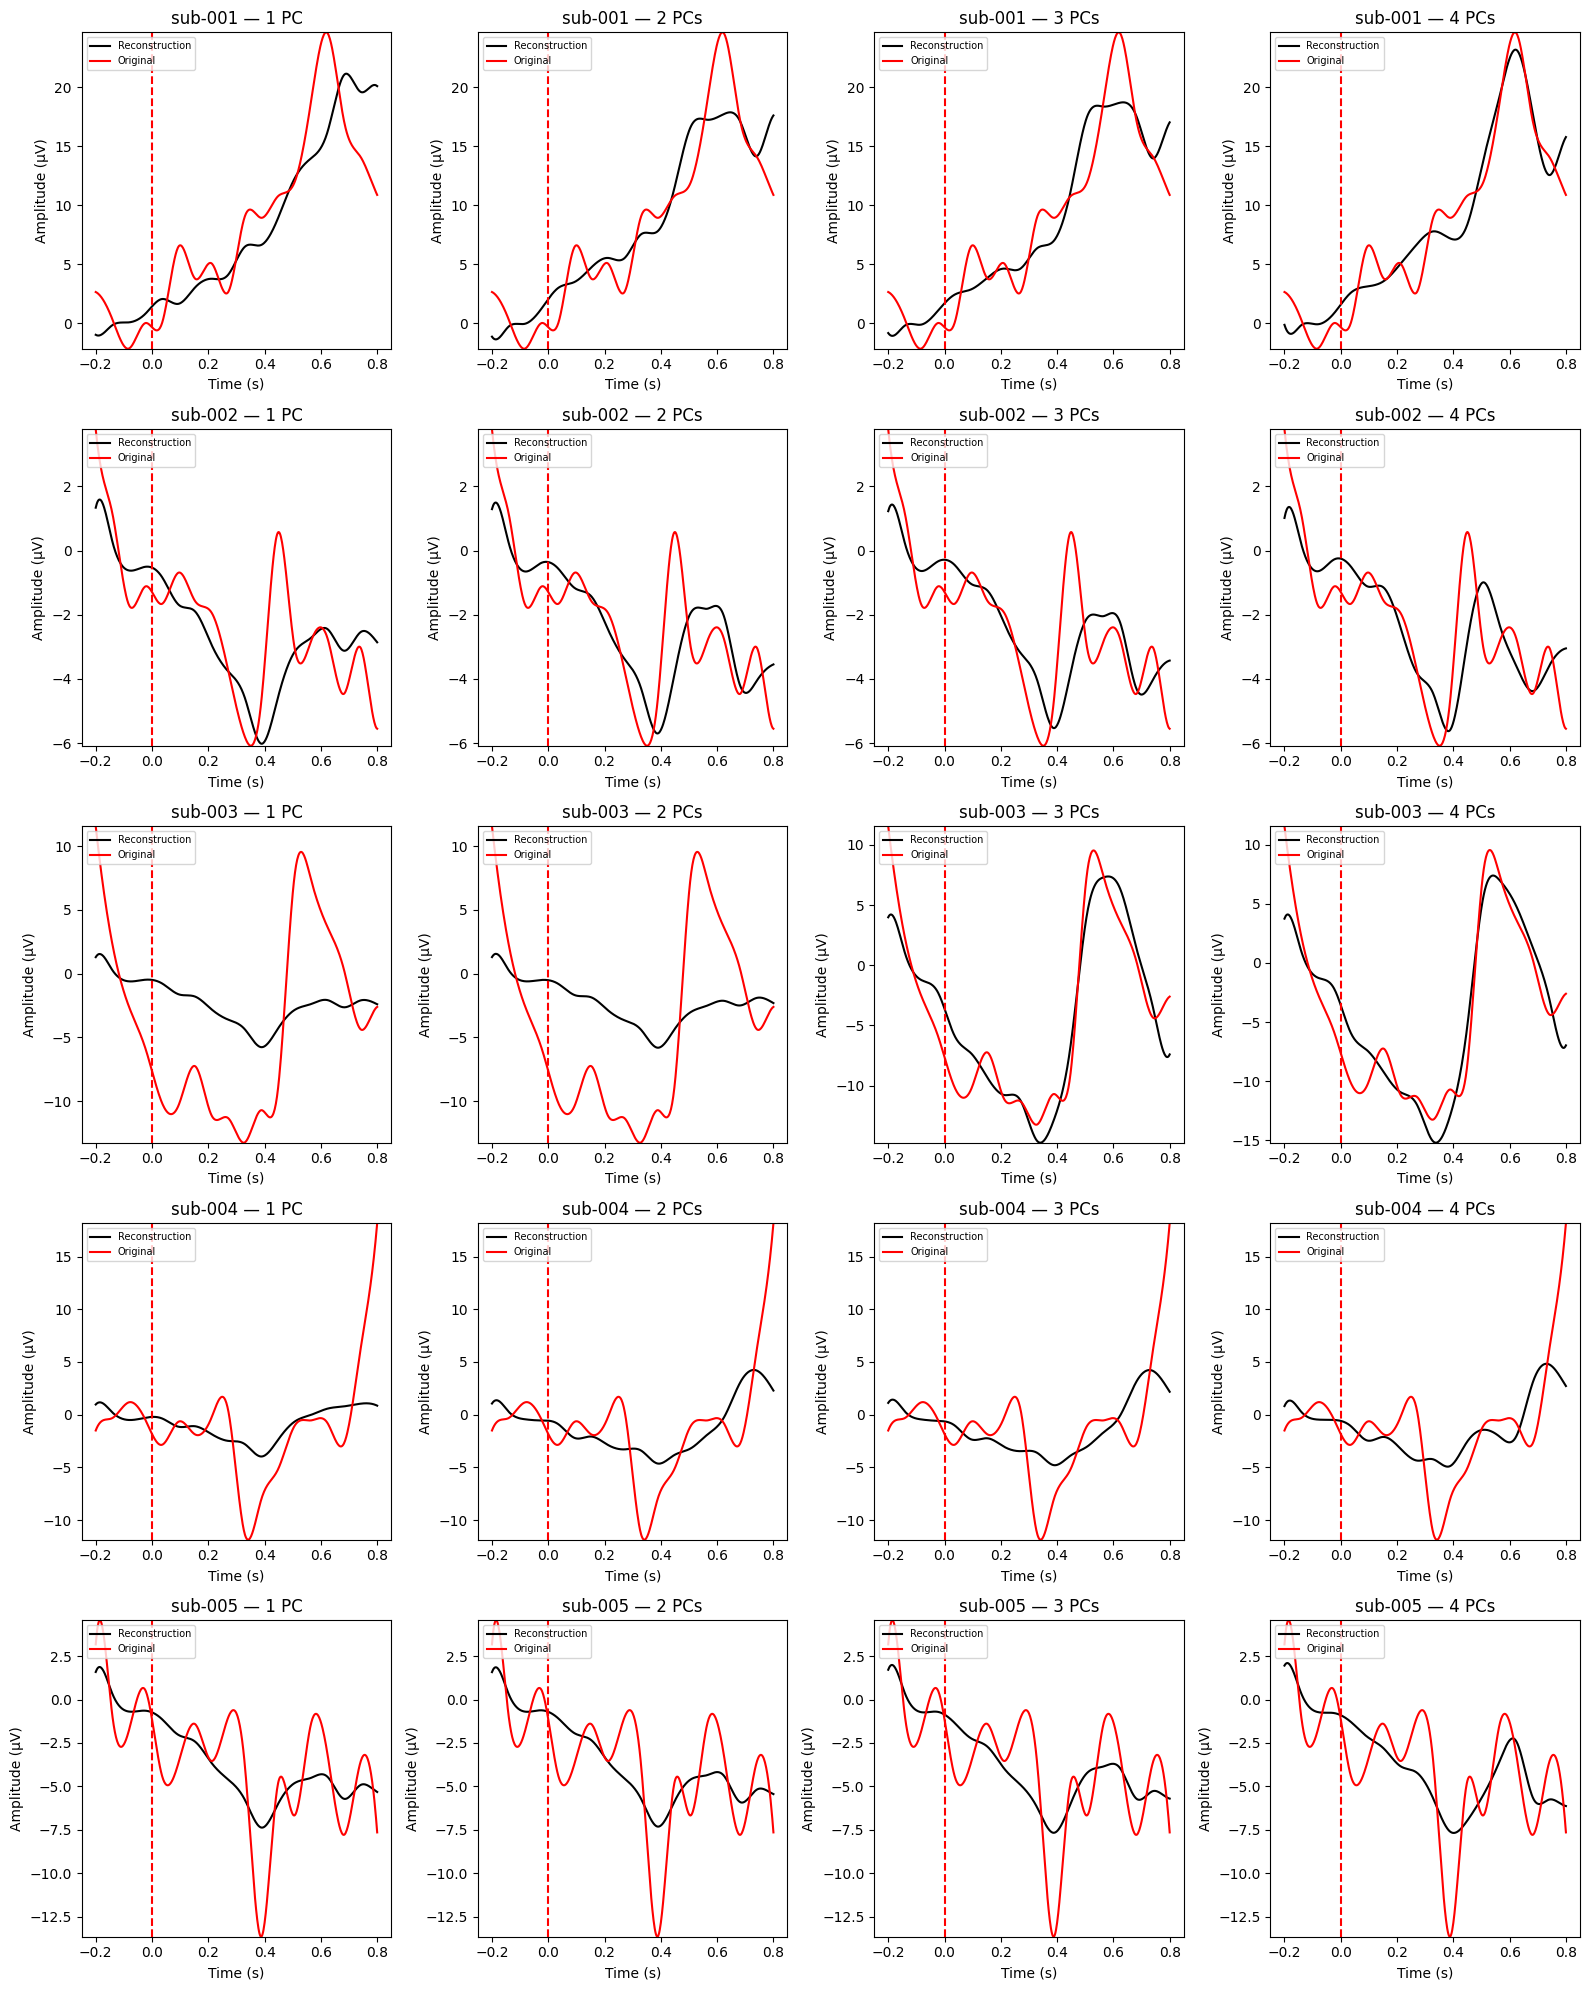

Saved: 16_pca_reconstruction.pdf


In [21]:
# 16: PCA reconstruction (first 5 subjects)
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
for i in range(5):
    orig = Y_eval[:, i]
    for k, ax in enumerate(axes[i]):
        recon = mean_vec + sum(
            scores[i, j] * harmonics[:, j] for j in range(k+1)
        )
        ylim = (min(orig.min(), recon.min()), max(orig.max(), recon.max()))
        ax.plot(t_fine, recon, color='black', linewidth=1.5, label='Reconstruction')
        ax.plot(t_fine, orig,  color='red',   linewidth=1.5, label='Original')
        ax.axvline(0, linestyle='--', color='red')
        ax.set_ylim(ylim)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude (µV)')
        ax.set_title(f'{subject_ids[i]} — {k+1} PC{"" if k==0 else "s"}')
        ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(out_dir / '16_pca_reconstruction.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 16_pca_reconstruction.pdf')


## Part 5: Varimax Rotation

In [22]:
from sklearn.utils.extmath import randomized_svd

# Varimax rotation of PCA harmonics
def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    """Varimax rotation of loading matrix Phi (n_features x n_components)"""
    p, k   = Phi.shape
    R      = np.eye(k)
    d_old  = 0
    for _ in range(q):
        L  = Phi @ R
        u, s, vt = np.linalg.svd(
            Phi.T @ (L**3 - (gamma/p) * L @ np.diag(np.diag(L.T @ L)))
        )
        R = u @ vt
        d = np.sum(s)
        if d_old != 0 and abs(d - d_old) / d < tol:
            break
        d_old = d
    return Phi @ R, R

harm_rotated, R_var = varimax(harmonics)   # (501, nharm)

# Rotated scores
scores_rot = scores @ np.linalg.inv(R_var).T

# Rotated explained variance (approximate)
var_rot = np.var(scores_rot, axis=0)
var_rot_prop = var_rot / var_rot.sum() * np.sum(var_prop)

print('VARIMAX variance proportions (approx):')
print(var_rot_prop)


VARIMAX variance proportions (approx):
[0.17307849 0.33822687 0.18700968 0.19303986]


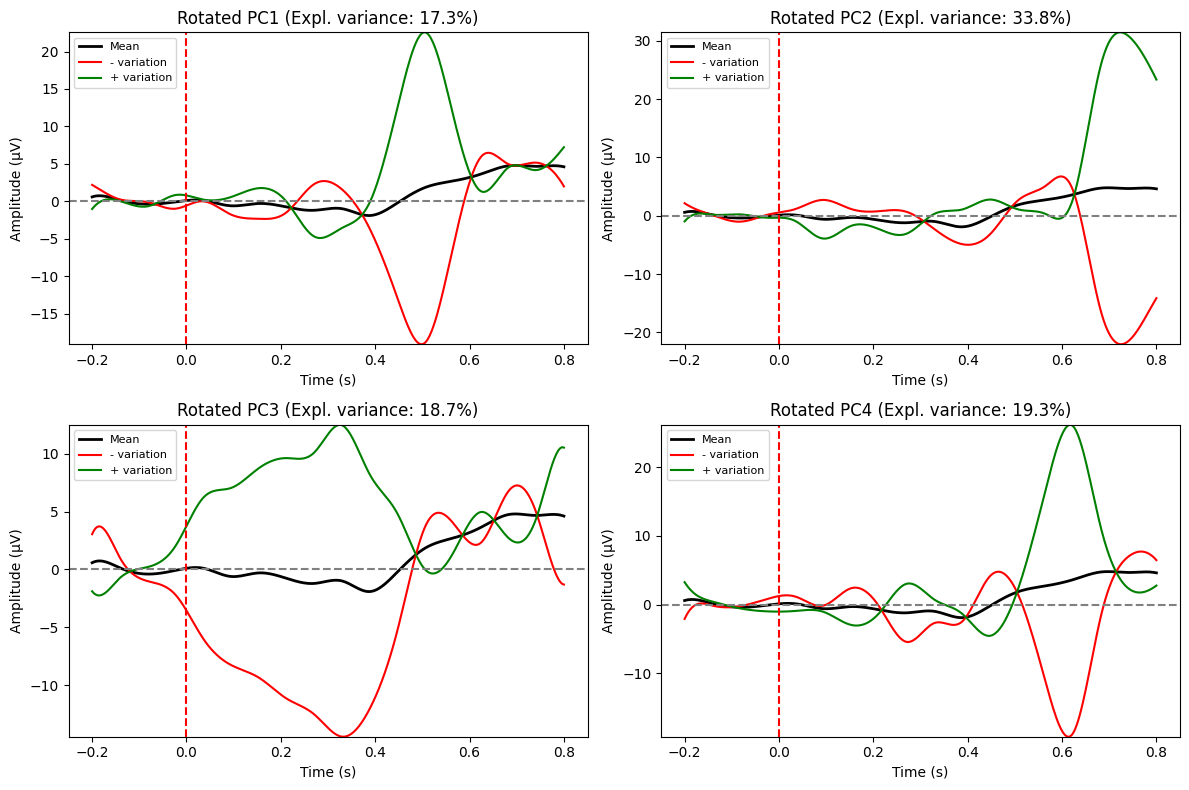

Saved: 17_varimax_plot.pdf


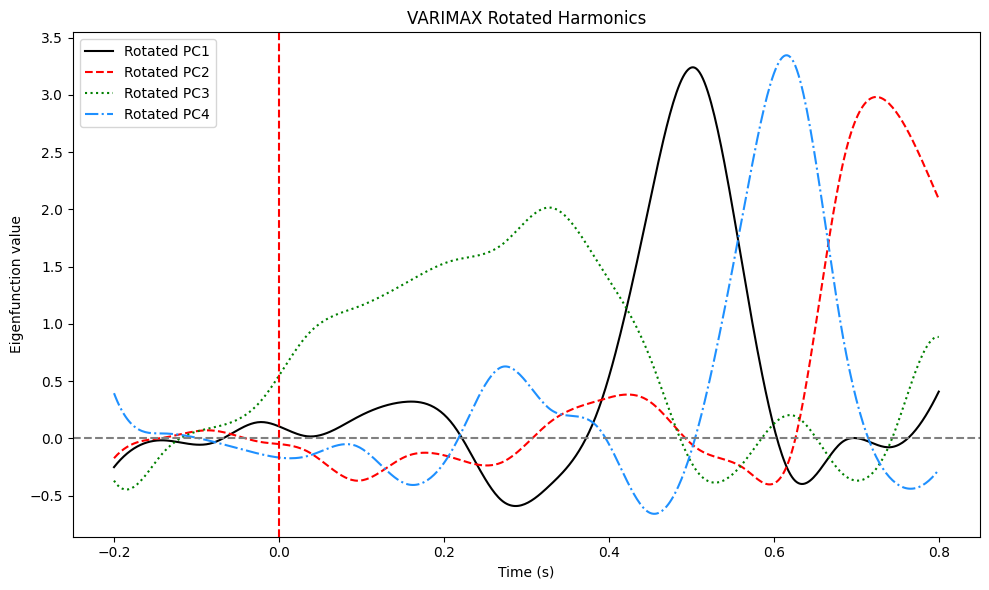

Saved: 18_varimax_harmonics.pdf


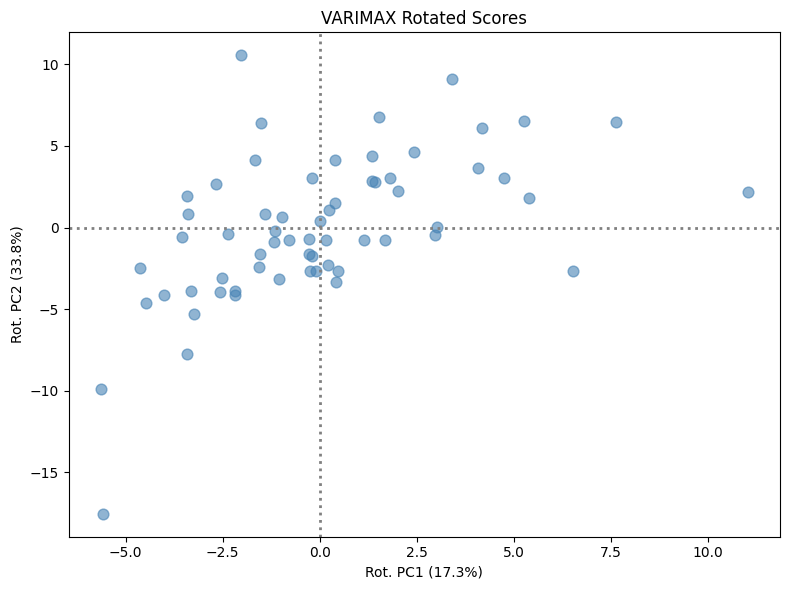

Saved: 19_varimax_scores.pdf


In [23]:
# 17: Varimax plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for k, ax in enumerate(axes.flat):
    fac  = np.sqrt(abs(var_rot[k]))
    f1   = mean_vec - c * fac * harm_rotated[:, k]
    f2   = mean_vec + c * fac * harm_rotated[:, k]
    ylim = (min(f1.min(), f2.min()), max(f1.max(), f2.max()))
    ax.plot(t_fine, mean_vec, color='black', linewidth=2, label='Mean')
    ax.plot(t_fine, f1, color='red',   linewidth=1.5, label='- variation')
    ax.plot(t_fine, f2, color='green', linewidth=1.5, label='+ variation')
    ax.axhline(0, linestyle='--', color='grey')
    ax.axvline(0, linestyle='--', color='red')
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'Rotated PC{k+1} (Expl. variance: {100*var_rot_prop[k]:.1f}%)')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(out_dir / '17_varimax_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 17_varimax_plot.pdf')

# 18: Varimax harmonics
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = ['black', 'red', 'green', 'dodgerblue']
for k in range(nharm):
    ax.plot(t_fine, harm_rotated[:, k], color=colors2[k],
            linestyle=['-','--',':','-.'][k], linewidth=1.5,
            label=f'Rotated PC{k+1}')
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Eigenfunction value')
ax.set_title('VARIMAX Rotated Harmonics')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / '18_varimax_harmonics.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 18_varimax_harmonics.pdf')

# 19: Varimax scores
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scores_rot[:, 0], scores_rot[:, 1], color='steelblue', alpha=0.6, s=60)
ax.axhline(0, linestyle=':', color='grey', linewidth=2)
ax.axvline(0, linestyle=':', color='grey', linewidth=2)
ax.set_xlabel(f'Rot. PC1 ({100*var_rot_prop[0]:.1f}%)')
ax.set_ylabel(f'Rot. PC2 ({100*var_rot_prop[1]:.1f}%)')
ax.set_title('VARIMAX Rotated Scores')
plt.tight_layout()
plt.savefig(out_dir / '19_varimax_scores.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 19_varimax_scores.pdf')


## Part 6: Functional Boxplots

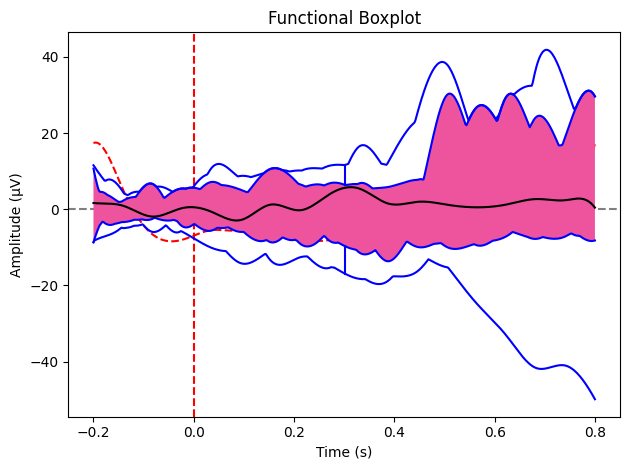

Saved: 20_boxplot_fd.pdf


In [24]:
# 20: Functional boxplot using skfda
boxplot = Boxplot(fd_eval)
fig = boxplot.plot()
ax = fig.axes[0]
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Functional Boxplot')
plt.tight_layout()
plt.savefig(out_dir / '20_boxplot_fd.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 20_boxplot_fd.pdf')

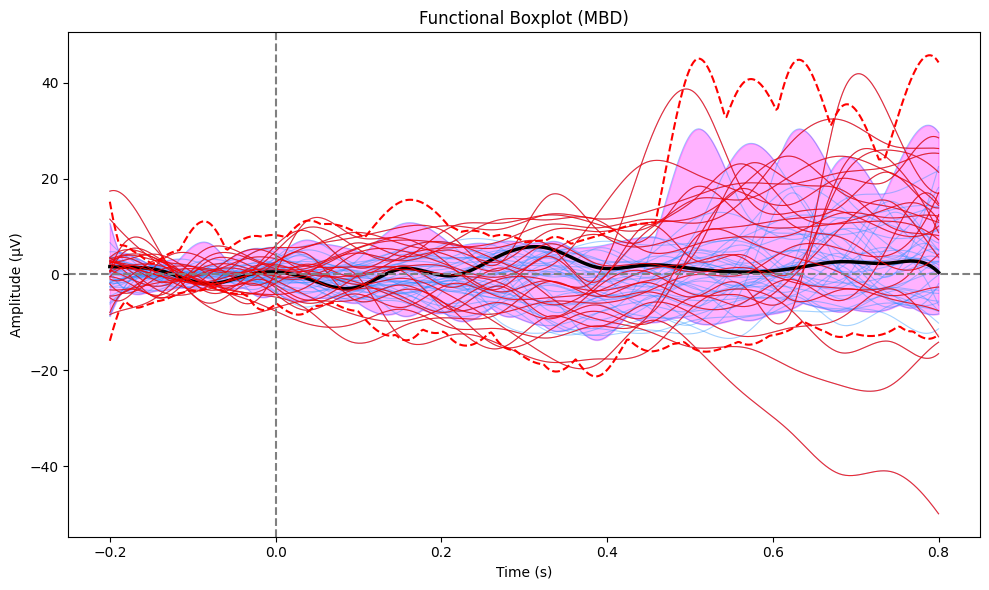

Saved: 21_fbplot_MBD.pdf


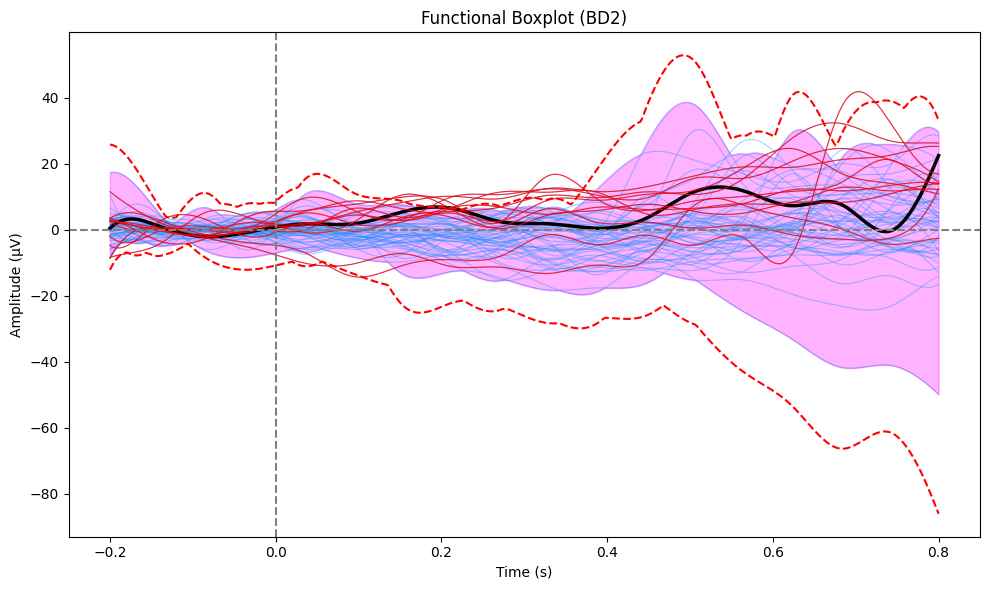

Saved: 22_fbplot_BD2.pdf


In [25]:
# 21/22: fbplot with MBD and BD
def functional_boxplot(Y, t, depth_vals, title, fname, factor=1.5):
    """Functional boxplot: median, central region, whiskers, outliers"""
    n       = Y.shape[1]
    n_50    = max(1, int(n * 0.5))
    idx_s   = np.argsort(depth_vals)[::-1]
    central = Y[:, idx_s[:n_50]]        # central 50%
    med     = Y[:, idx_s[0]]            # deepest = median
    env_lo  = central.min(axis=1)
    env_hi  = central.max(axis=1)
    fence_lo = med - factor * (med - env_lo)
    fence_hi = med + factor * (env_hi - med)
    outliers = [i for i in range(n)
                if np.any(Y[:, i] < fence_lo) or np.any(Y[:, i] > fence_hi)]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.fill_between(t, env_lo, env_hi, color='magenta', alpha=0.3)
    ax.plot(t, Y, color='dodgerblue', linewidth=0.8, alpha=0.4)
    ax.plot(t, med, color='black', linewidth=2.5)
    ax.plot(t, fence_lo, color='red', linestyle='--', linewidth=1.5)
    ax.plot(t, fence_hi, color='red', linestyle='--', linewidth=1.5)
    for i in outliers:
        ax.plot(t, Y[:, i], color='red', linewidth=0.8, alpha=0.8)
    ax.axhline(0, linestyle='--', color='grey')
    v0 = t[np.argmin(np.abs(t - 0))]
    ax.axvline(v0, linestyle='--', color='grey')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_dir / fname, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

functional_boxplot(Y_eval, t_fine, mbd_depth, 'Functional Boxplot (MBD)', '21_fbplot_MBD.pdf')
functional_boxplot(Y_eval, t_fine, bd_depth,  'Functional Boxplot (BD2)', '22_fbplot_BD2.pdf')


## Part 7: Band Depth and Modified Band Depth

Band Depth:
  sub-001: 0.0323
  sub-002: 0.0323
  sub-003: 0.0323
  sub-004: 0.0323
  sub-005: 0.0323
  sub-006: 0.0323
  sub-007: 0.0323
  sub-008: 0.0323
  sub-009: 0.0323
  sub-010: 0.0323
  sub-011: 0.0323
  sub-012: 0.0323
  sub-013: 0.0323
  sub-014: 0.0323
  sub-016: 0.0323
  sub-017: 0.0323
  sub-019: 0.0323
  sub-021: 0.0323
  sub-022: 0.0323
  sub-024: 0.0323
  sub-025: 0.0323
  sub-027: 0.0323
  sub-028: 0.0323
  sub-029: 0.0323
  sub-030: 0.0323
  sub-031: 0.0323
  sub-032: 0.0323
  sub-033: 0.0323
  sub-034: 0.0323
  sub-035: 0.0323
  sub-036: 0.0323
  sub-037: 0.0323
  sub-038: 0.0323
  sub-039: 0.0323
  sub-040: 0.0323
  sub-041: 0.0323
  sub-042: 0.0323
  sub-043: 0.0323
  sub-046: 0.0323
  sub-047: 0.0323
  sub-048: 0.0323
  sub-049: 0.0323
  sub-050: 0.0323
  sub-052: 0.0323
  sub-053: 0.0323
  sub-055: 0.0323
  sub-057: 0.0323
  sub-058: 0.0323
  sub-059: 0.0323
  sub-060: 0.0323
  sub-061: 0.0323
  sub-062: 0.0323
  sub-063: 0.0323
  sub-064: 0.0323
  sub-065: 0.032

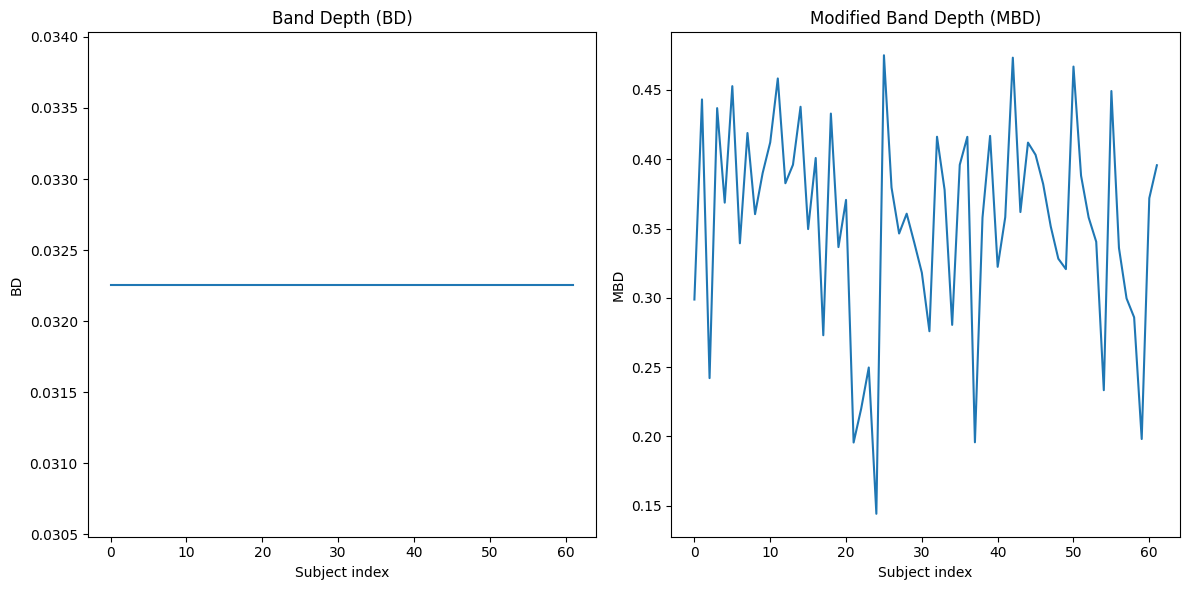

Saved: 23_band_depths.pdf


In [26]:
print('Band Depth:')
for sid, d in zip(subject_ids, bd_depth):
    print(f'  {sid}: {d:.4f}')

print('\nModified Band Depth:')
for sid, d in zip(subject_ids, mbd_depth):
    print(f'  {sid}: {d:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].plot(bd_depth,  linewidth=1.5)
axes[0].set_title('Band Depth (BD)')
axes[0].set_xlabel('Subject index')
axes[0].set_ylabel('BD')
axes[1].plot(mbd_depth, linewidth=1.5)
axes[1].set_title('Modified Band Depth (MBD)')
axes[1].set_xlabel('Subject index')
axes[1].set_ylabel('MBD')
plt.tight_layout()
plt.savefig(out_dir / '23_band_depths.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 23_band_depths.pdf')

## Part 8: MUOD Outlier Detection

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__replace__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'directional_outlyingness', 'functional_directional_outlyingness', 'mean_directional_outlyingness', 'variation_directional_outlyingness']
MUOD outliers (MS-plot based):
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1]


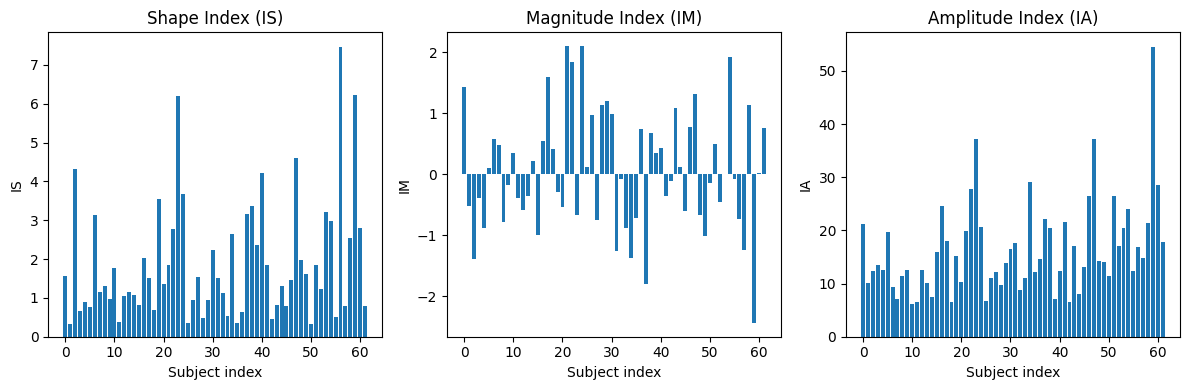

Saved: 24_muod.pdf


In [27]:
ms = MSPlotOutlierDetector()
labels = ms.fit_predict(fd_eval)
stats = directional_outlyingness_stats(fd_eval)
print(dir(stats))
shape_idx = stats.variation_directional_outlyingness
mag_idx = stats.mean_directional_outlyingness.squeeze()
amp_idx = np.max(np.abs(Y_eval - mean_curve[:, np.newaxis]), axis=0)
print('MUOD outliers (MS-plot based):')
print(labels)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(range(n_subj), shape_idx, linewidth=1.5)
axes[0].set_title('Shape Index (IS)')
axes[0].set_xlabel('Subject index')
axes[0].set_ylabel('IS')
axes[1].bar(range(n_subj), mag_idx, linewidth=1.5)
axes[1].set_title('Magnitude Index (IM)')
axes[1].set_xlabel('Subject index')
axes[1].set_ylabel('IM')
axes[2].bar(range(n_subj), amp_idx, linewidth=1.5)
axes[2].set_title('Amplitude Index (IA)')
axes[2].set_xlabel('Subject index')
axes[2].set_ylabel('IA')
plt.tight_layout()
plt.savefig(out_dir / '24_muod.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 24_muod.pdf')


## Part 9: Rainbow Plots

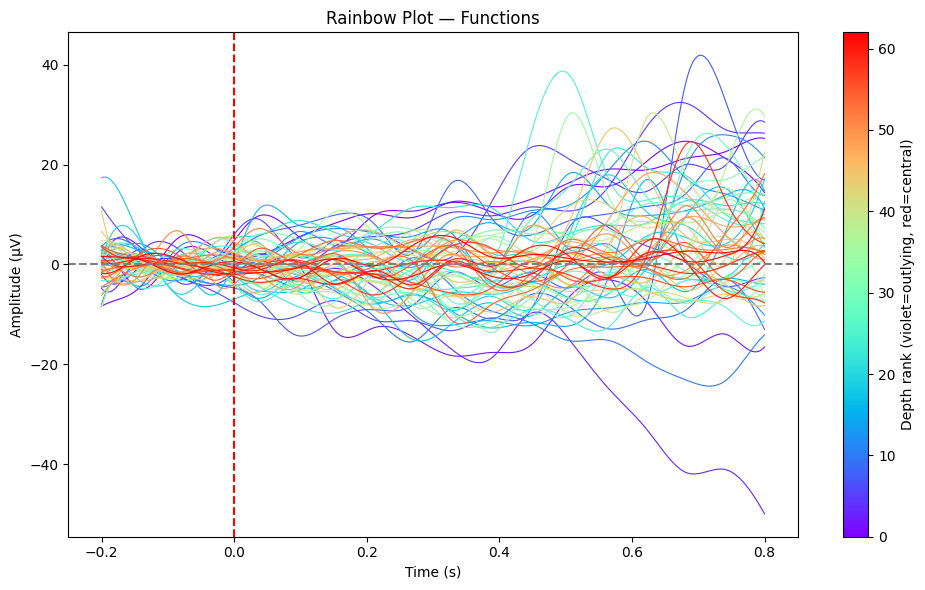

Saved: 25_rainbow_functions.pdf


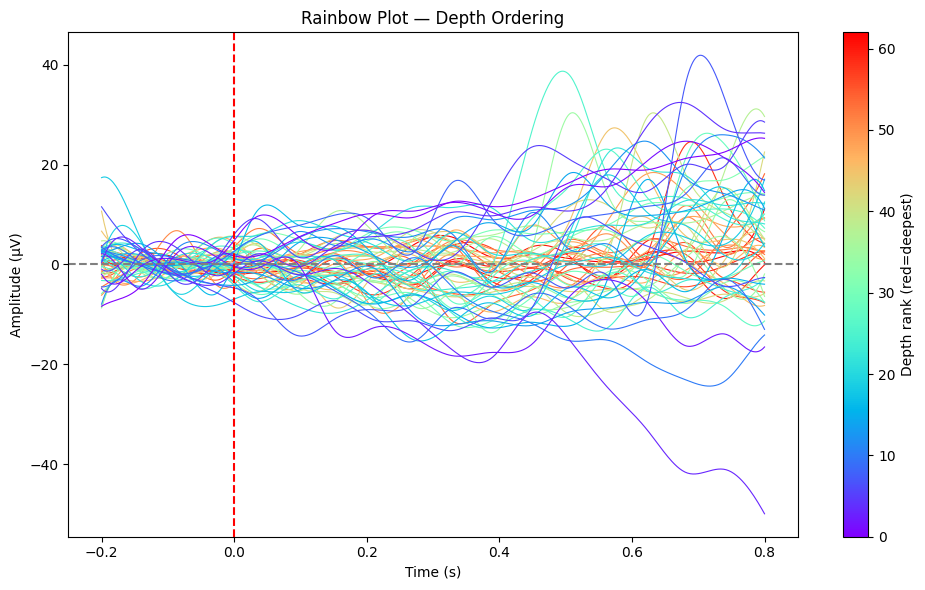

Saved: 26_rainbow_depth.pdf


In [28]:
# Rainbow colormap ordered by MBD depth (most central = red, most outlying = violet)
order     = np.argsort(mbd_depth)          # ascending depth = most outlying first
n_colors  = n_subj
colors_rbow = cm.rainbow(np.linspace(0, 1, n_colors))

# 25: Rainbow functions
fig, ax = plt.subplots(figsize=(10, 6))
for rank, idx in enumerate(order):
    ax.plot(t_fine, Y_eval[:, idx], color=colors_rbow[rank], linewidth=0.8)
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Rainbow Plot — Functions')
sm = plt.cm.ScalarMappable(cmap='rainbow', norm=plt.Normalize(0, n_subj))
plt.colorbar(sm, ax=ax, label='Depth rank (violet=outlying, red=central)')
plt.tight_layout()
plt.savefig(out_dir / '25_rainbow_functions.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 25_rainbow_functions.pdf')

# 26: Rainbow depth
fig, ax = plt.subplots(figsize=(10, 6))
depth_order = np.argsort(mbd_depth)[::-1]   # most central first
for rank, idx in enumerate(depth_order):
    ax.plot(t_fine, Y_eval[:, idx], color=colors_rbow[n_subj-1-rank], linewidth=0.8)
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Rainbow Plot — Depth Ordering')
plt.colorbar(sm, ax=ax, label='Depth rank (red=deepest)')
plt.tight_layout()
plt.savefig(out_dir / '26_rainbow_depth.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 26_rainbow_depth.pdf')


## Part 10: Functional Bagplot

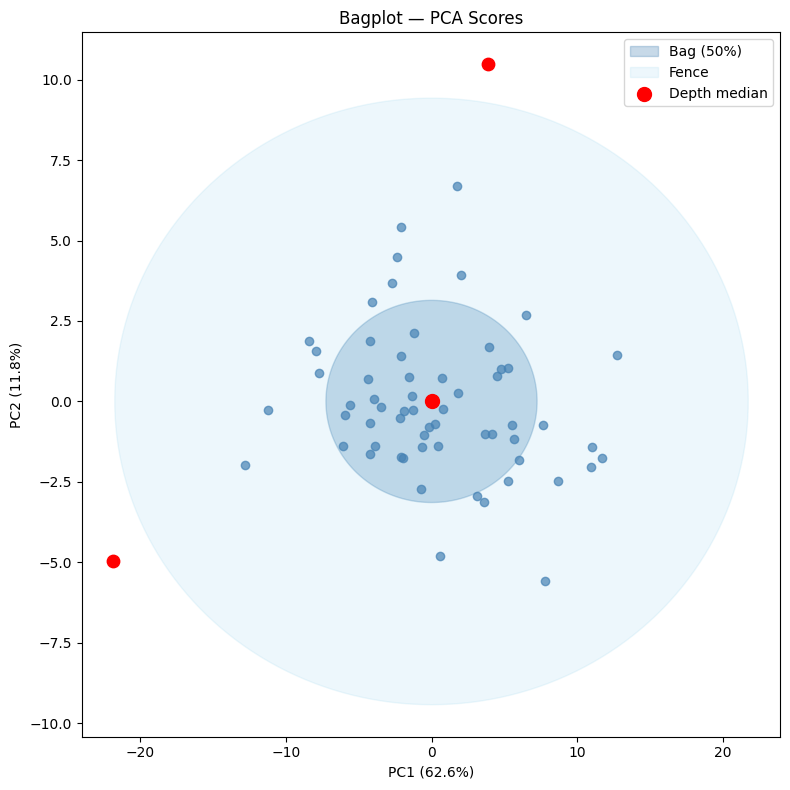

Saved: 27_bagplot_bivariate.pdf


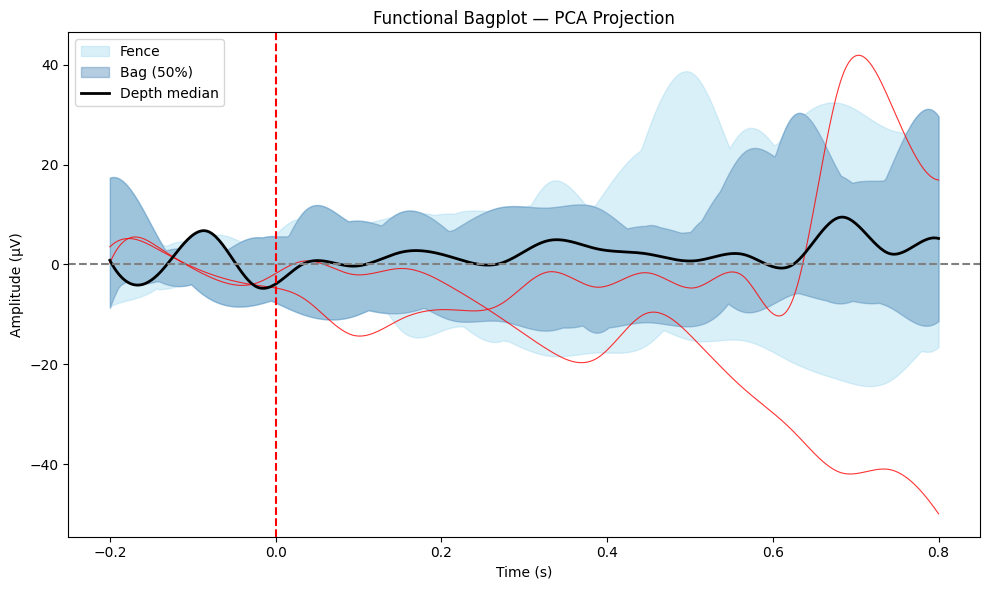

Saved: 28_bagplot_functional.pdf


In [29]:
from scipy.stats import chi2 as chi2_dist

# Bagplot using PC1 and PC2 scores
pc_scores = scores[:, :2]   # (n_subj, 2)

def halfspace_depth_2d(point, data):
    """Tukey halfspace depth of a point wrt data."""
    n = len(data)
    depths = []
    for i in range(n):
        for j in range(i+1, n):
            v = data[j] - data[i]
            if np.linalg.norm(v) < 1e-10: continue
            n_vec = np.array([-v[1], v[0]])
            side = (data - point) @ n_vec
            depths.append(min(np.sum(side >= 0), np.sum(side <= 0)))
    return min(depths) / n if depths else 0

# Simplified: use Mahalanobis distance for bag/fence
cov2   = np.cov(pc_scores.T)
mu2    = pc_scores.mean(axis=0)
diff   = pc_scores - mu2
mah_d  = np.sqrt(np.einsum('ij,jk,ik->i', diff, np.linalg.inv(cov2), diff))

# Bag = inner 50% (Mahalanobis < chi2(2, 0.5))
bag_r   = np.sqrt(chi2_dist.ppf(0.5, df=2))
fence_r = 3 * bag_r
outliers_2d = np.where(mah_d > fence_r)[0]

theta = np.linspace(0, 2*np.pi, 200)
eigvals, eigvecs = np.linalg.eigh(cov2)

def ellipse(r):
    pts = r * np.column_stack([np.cos(theta), np.sin(theta)])
    return (pts @ np.diag(np.sqrt(eigvals)) @ eigvecs.T) + mu2

# 27: Bivariate bagplot
fig, ax = plt.subplots(figsize=(8, 8))
bag_pts   = ellipse(bag_r)
fence_pts = ellipse(fence_r)
ax.fill(bag_pts[:,0],   bag_pts[:,1],   alpha=0.3, color='steelblue', label='Bag (50%)')
ax.fill(fence_pts[:,0], fence_pts[:,1], alpha=0.15, color='skyblue', label='Fence')
ax.scatter(pc_scores[:,0], pc_scores[:,1], color='steelblue', alpha=0.7, zorder=3)
ax.scatter(*mu2, color='red', s=100, zorder=5, label='Depth median')
for i in outliers_2d:
    ax.scatter(pc_scores[i,0], pc_scores[i,1], color='red', s=80, zorder=4)
ax.set_xlabel(f'PC1 ({100*var_prop[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({100*var_prop[1]:.1f}%)')
ax.set_title('Bagplot — PCA Scores')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / '27_bagplot_bivariate.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 27_bagplot_bivariate.pdf')

# 28: Functional bagplot
bag_mask   = mah_d <= bag_r
fence_mask = mah_d <= fence_r
bag_lo   = Y_eval[:, bag_mask].min(axis=1)
bag_hi   = Y_eval[:, bag_mask].max(axis=1)
fence_lo = Y_eval[:, fence_mask].min(axis=1)
fence_hi = Y_eval[:, fence_mask].max(axis=1)
depth_med_idx = np.argmin(mah_d)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(t_fine, fence_lo, fence_hi, color='skyblue',   alpha=0.3, label='Fence')
ax.fill_between(t_fine, bag_lo,   bag_hi,   color='steelblue', alpha=0.4, label='Bag (50%)')
for i in outliers_2d:
    ax.plot(t_fine, Y_eval[:, i], color='red', linewidth=0.8, alpha=0.8)
ax.plot(t_fine, Y_eval[:, depth_med_idx], color='black', linewidth=2, label='Depth median')
ax.axhline(0, linestyle='--', color='grey')
ax.axvline(0, linestyle='--', color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Functional Bagplot — PCA Projection')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / '28_bagplot_functional.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: 28_bagplot_functional.pdf')


## Part 11: HDR Boxplot

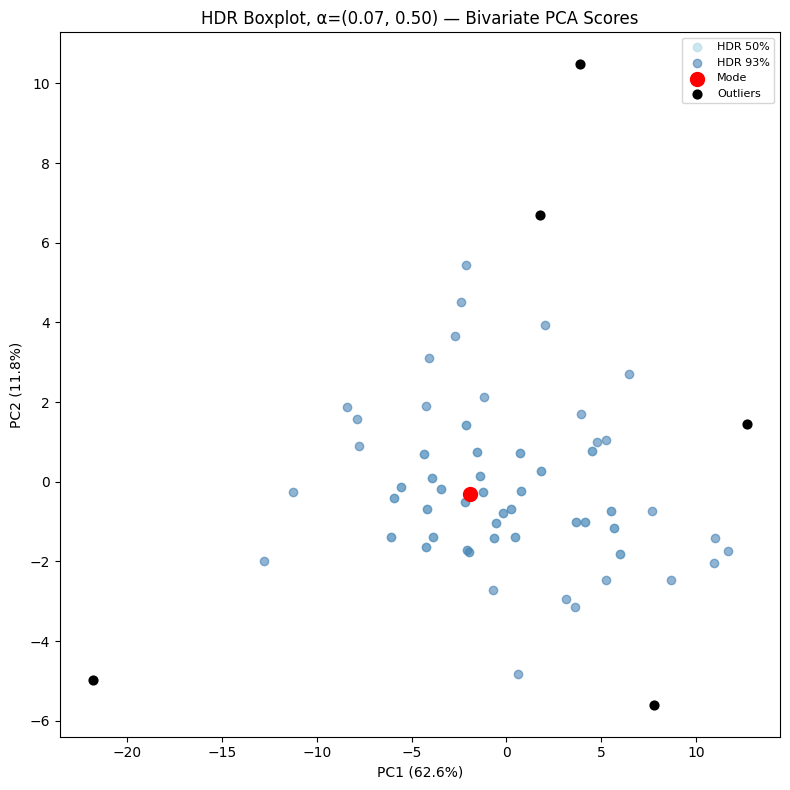

Saved: 29_hdr_bivariate_007.pdf


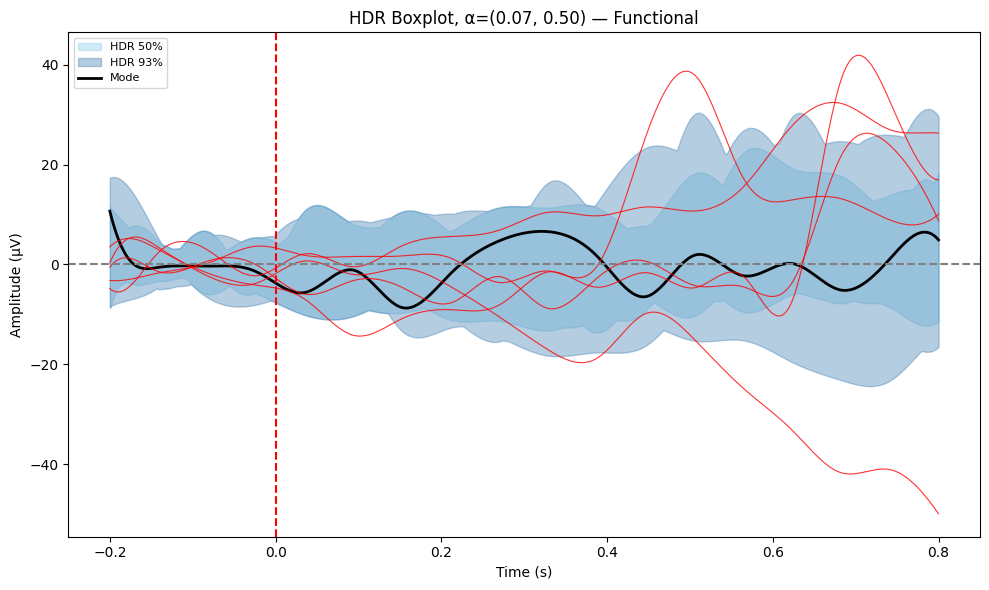

Saved: 31_hdr_functional_007.pdf


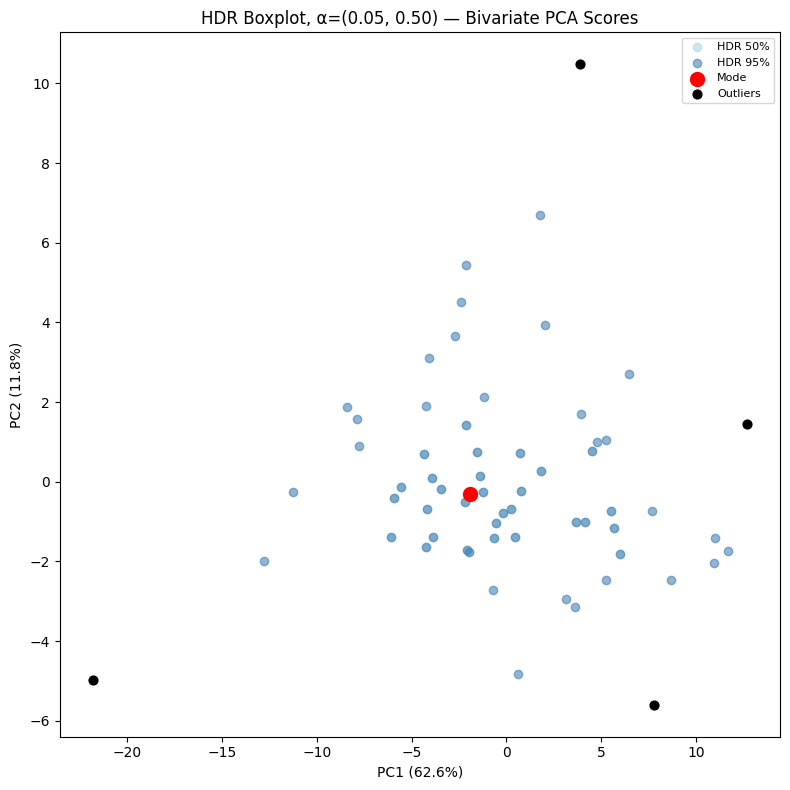

Saved: 30_hdr_bivariate_005.pdf


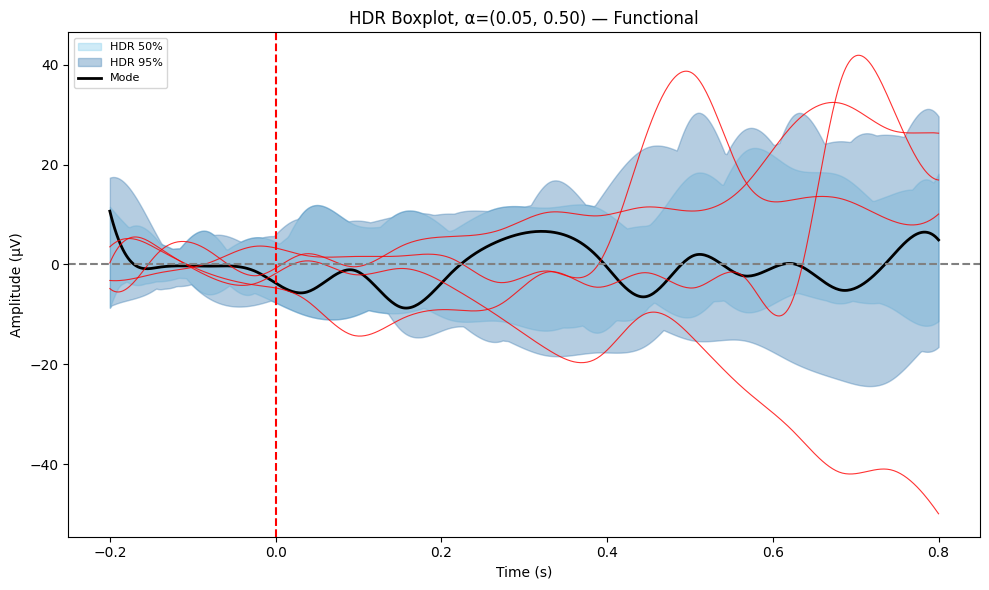

Saved: 32_hdr_functional_005.pdf


In [30]:
from scipy.stats import gaussian_kde

def hdr_boxplot(pc_scores, Y_eval, t_fine, alpha_vals, title_prefix, fname_bi, fname_fn):
    """HDR boxplot using KDE on PC1/PC2 scores."""
    kde    = gaussian_kde(pc_scores.T)
    dens   = kde(pc_scores.T)
    thresholds = [np.quantile(dens, a) for a in alpha_vals]

    fig, ax = plt.subplots(figsize=(8, 8))
    colors_hdr = ['lightblue', 'steelblue']
    for thresh, col, a in zip(thresholds[::-1], colors_hdr, alpha_vals[::-1]):
        mask = dens >= thresh
        ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1],
                   color=col, alpha=0.6, label=f'HDR {int((1-a)*100)}%')
    mode_idx = np.argmax(dens)
    ax.scatter(*pc_scores[mode_idx], color='red', s=100, zorder=5, label='Mode')
    out_mask = dens < thresholds[0]
    ax.scatter(pc_scores[out_mask, 0], pc_scores[out_mask, 1],
               color='black', s=40, zorder=4, label='Outliers')
    ax.set_xlabel(f'PC1 ({100*var_prop[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({100*var_prop[1]:.1f}%)')
    ax.set_title(f'{title_prefix} — Bivariate PCA Scores')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / fname_bi, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname_bi}')

    # Functional version
    fig, ax = plt.subplots(figsize=(10, 6))
    for thresh, col, a in zip(thresholds[::-1], ['skyblue','steelblue'], alpha_vals[::-1]):
        mask = dens >= thresh
        lo = Y_eval[:, mask].min(axis=1)
        hi = Y_eval[:, mask].max(axis=1)
        ax.fill_between(t_fine, lo, hi, color=col, alpha=0.4,
                        label=f'HDR {int((1-a)*100)}%')
    ax.plot(t_fine, Y_eval[:, mode_idx], color='black', linewidth=2, label='Mode')
    for i in np.where(out_mask)[0]:
        ax.plot(t_fine, Y_eval[:, i], color='red', linewidth=0.8, alpha=0.8)
    ax.axhline(0, linestyle='--', color='grey')
    ax.axvline(0, linestyle='--', color='red')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'{title_prefix} — Functional')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / fname_fn, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname_fn}')

hdr_boxplot(pc_scores, Y_eval, t_fine, [0.07, 0.5],
            'HDR Boxplot, α=(0.07, 0.50)',
            '29_hdr_bivariate_007.pdf', '31_hdr_functional_007.pdf')
hdr_boxplot(pc_scores, Y_eval, t_fine, [0.05, 0.5],
            'HDR Boxplot, α=(0.05, 0.50)',
            '30_hdr_bivariate_005.pdf', '32_hdr_functional_005.pdf')


## Part 12: Functional Outlier Detection

In [31]:
from skfda.exploratory.outliers import MSPlotOutlierDetector
import contextlib

fd_eval_obj = FDataGrid(data_matrix=Y_eval.T, grid_points=t_fine)

results_txt = out_dir / '33_foutliers_results.txt'
with open(results_txt, 'w') as sink:

    def tee(msg):
        print(msg)
        sink.write(msg + '\n')

    tee('=== robMah (Mahalanobis distance-based) ===')
    outlier_scores = mah_d
    threshold_mah  = np.mean(mah_d) + 2.5 * np.std(mah_d)
    outliers_mah   = [subject_ids[i] for i in np.where(mah_d > threshold_mah)[0]]
    tee(f'Outliers (Mahalanobis > {threshold_mah:.2f}): {outliers_mah}')

    tee('\n=== depth.trim (MBD-based trimming) ===')
    threshold_mbd  = np.quantile(mbd_depth, 0.1)
    outliers_mbd   = [subject_ids[i] for i in np.where(mbd_depth < threshold_mbd)[0]]
    tee(f'Outliers (MBD < 10th percentile = {threshold_mbd:.4f}): {outliers_mbd}')

    tee('\n=== depth.pond (BD-based) ===')
    threshold_bd   = np.quantile(bd_depth, 0.1)
    outliers_bd    = [subject_ids[i] for i in np.where(bd_depth < threshold_bd)[0]]
    tee(f'Outliers (BD < 10th percentile = {threshold_bd:.4f}): {outliers_bd}')

    tee('\n=== MSPlot outliers ===')
    ms_labels = ms.fit_predict(fd_eval_obj)
    outliers_ms = [subject_ids[i] for i, l in enumerate(ms_labels) if l == -1]
    tee(f'Outliers (MS-plot): {outliers_ms}')

    tee('\n=== Amplitude outliers (IQR-based) ===')
    q1, q3 = np.quantile(amp_idx, 0.25), np.quantile(amp_idx, 0.75)
    iqr    = q3 - q1
    outliers_amp = [subject_ids[i] for i in np.where(amp_idx > q3 + 1.5*iqr)[0]]
    tee(f'Outliers (amplitude IQR): {outliers_amp}')

print(f'Saved: 33_foutliers_results.txt')
print('\n*** All EDA outputs saved. Done! ***')


=== robMah (Mahalanobis distance-based) ===
Outliers (Mahalanobis > 3.12): ['sub-029', 'sub-071']

=== depth.trim (MBD-based trimming) ===
Outliers (MBD < 10th percentile = 0.2428): ['sub-003', 'sub-027', 'sub-028', 'sub-030', 'sub-043', 'sub-065', 'sub-071']

=== depth.pond (BD-based) ===
Outliers (BD < 10th percentile = 0.0323): []

=== MSPlot outliers ===
Outliers (MS-plot): ['sub-068', 'sub-071']

=== Amplitude outliers (IQR-based) ===
Outliers (amplitude IQR): ['sub-029', 'sub-058', 'sub-071']
Saved: 33_foutliers_results.txt

*** All EDA outputs saved. Done! ***
